In [33]:
import matplotlib.pyplot as plt
from pathlib import Path
import pickle
import numpy as np

In [34]:
data_dir = Path("/Users/leekaijen/t7ssd/dim2feats")

In [35]:
for file in data_dir.iterdir():
    if file.is_file() and not file.name.startswith('._'):
        print(f"{file.name}")

cma_10_tla.pkl
cma_25_tla.pkl
cma_50_tla.pkl
ilhs_10_tla.pkl
ilhs_25_tla.pkl
ilhs_50_ela.pkl
ilhs_50_tla.pkl
lhs_10_tla.pkl
lhs_25_tla.pkl
lhs_50_ela.pkl
lhs_50_tla.pkl
lhs_75_ela.pkl
lhs_100_ela.pkl
sobol_10_tla.pkl
sobol_25_tla.pkl
sobol_50_tla.pkl
uniform_10_tla.pkl
uniform_25_tla.pkl
uniform_50_ela.pkl
uniform_50_tla.pkl
uniform_75_ela.pkl


In [36]:
# with open('/Users/leekaijen/t7ssd/dim2feats/cma_10_tla.pkl', 'rb') as f:
#     cma_10_tla = pickle.load(f)

In [37]:
# len(cma_10_tla[(1,1,2)]['volume']['h0'])

In [38]:
# cma_10_tla[(1,1,2)]['volume']['h0'][1].shape

In [39]:
# cma_10_tla[(1,1,2)]['axis']['h1'][1]


In [40]:
# with open('/Users/leekaijen/t7ssd/dim2feats/cma_25_tla.pkl', 'rb') as f:
#     cma_25_tla = pickle.load(f)

In [41]:
# cma_25_tla[(1,1,2)]['volume']['h0'][1].shape


In [42]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [48]:
def load_cv_data(cv_file):
    """Load CV results from pickle file."""
    with open(cv_file, 'rb') as f:
        data = pickle.load(f)
    return data

    cv_file = Path("/Users/leekaijen/t7ssd/TLA_CV/tla_cv.pkl")
    cv_data = load_cv_data(cv_file)

    print(f"Found {len(cv_data)} configurations")
    print(f"Creating plots...\n")


In [51]:



def parse_key(key_name):
    """
    Parse key name to extract sampling technique and sample size.

    Args:
        key_name: e.g., "cma_10", "uniform_50"

    Returns:
        tuple: (technique, sample_size)
    """
    parts = key_name.rsplit('_', 1)
    technique = parts[0]
    sample_size = int(parts[1])
    return technique, sample_size


def compute_function_avg_cv(cv_dict):
    """
    Compute average CV per function across all instances and dimensions.

    Args:
        cv_dict: Dictionary with keys (function, instance, dim)

    Returns:
        dict: {function_id: avg_cv}
    """
    function_cvs = defaultdict(list)

    for key, transforms in cv_dict.items():
        function, instance, dim = key

        # Collect all CV values for this function
        for transform in ['volume', 'axis']:
            if transform not in transforms:
                continue

            for homology in ['h0', 'h1', 'h2']:
                if transforms[transform][homology] is None:
                    continue

                cv_array = transforms[transform][homology]

                # Compute mean CV for this specific configuration
                mean_cv = np.nanmean(cv_array)

                if not np.isnan(mean_cv):
                    function_cvs[function].append(mean_cv)

    # Average across all instances/dims/transforms/homologies for each function
    function_avg = {func: np.mean(cvs) for func, cvs in function_cvs.items()}

    return function_avg


def plot_cv_evolution(cv_data):
    """
    Create plots showing CV evolution across sample sizes for each technique.

    Args:
        cv_data: Loaded CV dictionary
        output_dir: Directory to save plots
    """
    # output_path = Path(output_dir)
    # output_path.mkdir(parents=True, exist_ok=True)

    # Organize data by technique
    technique_data = defaultdict(lambda: defaultdict(dict))

    for key_name, cv_dict in cv_data.items():
        technique, sample_size = parse_key(key_name)

        # Compute average CV per function
        function_avg_cv = compute_function_avg_cv(cv_dict)

        technique_data[technique][sample_size] = function_avg_cv

    # Create a plot for each sampling technique
    for technique, sample_size_data in technique_data.items():
        print(f"Creating plot for: {technique}")

        # Get all sample sizes and sort them
        sample_sizes = sorted(sample_size_data.keys())

        # Get all functions (should be 1-24)
        all_functions = set()
        for func_dict in sample_size_data.values():
            all_functions.update(func_dict.keys())
        all_functions = sorted(all_functions)

        # Create the plot
        fig, ax = plt.subplots(figsize=(12, 8))

        # Plot a line for each function
        for function in all_functions:
            cvs = []
            sizes = []

            for sample_size in sample_sizes:
                if function in sample_size_data[sample_size]:
                    cvs.append(sample_size_data[sample_size][function])
                    sizes.append(sample_size)

            if cvs:  # Only plot if we have data
                ax.plot(sizes, cvs, marker='o', label=f'F{function}', alpha=0.7)

        ax.set_xlabel('Sample Size', fontsize=12)
        ax.set_ylabel('Average Coefficient of Variation', fontsize=12)
        ax.set_title(f'CV Evolution Across Sample Sizes: {technique.upper()}',
                     fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)

        # Add legend (may be crowded with 24 functions)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
                 ncol=2, fontsize=8)

        plt.tight_layout()

        # Save plot
        # plot_file = output_path / f'{technique}_cv_evolution.png'
        # plt.savefig(plot_file, dpi=300, bbox_inches='tight')
        # print(f"  Saved: {plot_file}")
        plt.show()
        plt.close()

        # Also create a summary plot with mean and std across all functions
        fig, ax = plt.subplots(figsize=(10, 6))

        mean_cvs = []
        std_cvs = []

        for sample_size in sample_sizes:
            func_cvs = list(sample_size_data[sample_size].values())
            mean_cvs.append(np.mean(func_cvs))
            std_cvs.append(np.std(func_cvs))

        mean_cvs = np.array(mean_cvs)
        std_cvs = np.array(std_cvs)

        ax.plot(sample_sizes, mean_cvs, marker='o', linewidth=2,
                label='Mean CV', color='blue')
        ax.fill_between(sample_sizes,
                        mean_cvs - std_cvs,
                        mean_cvs + std_cvs,
                        alpha=0.3, color='blue', label='±1 STD')

        ax.set_xlabel('Sample Size', fontsize=12)
        ax.set_ylabel('Average Coefficient of Variation', fontsize=12)
        ax.set_title(f'Mean CV Across All Functions: {technique.upper()}',
                     fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend()

        plt.tight_layout()

        # # Save summary plot
        # summary_file = output_path / f'{technique}_cv_summary.png'
        # plt.savefig(summary_file, dpi=300, bbox_inches='tight')
        # print(f"  Saved: {summary_file}")
        plt.show()
        plt.close()

/var/folders/2x/yr46rn912_91htch_br0s2x80000gn/T/ipykernel_24186/1290804737.py:44: RuntimeWarning: Mean of empty slice
  mean_cv = np.nanmean(cv_array)


Creating plot for: cma


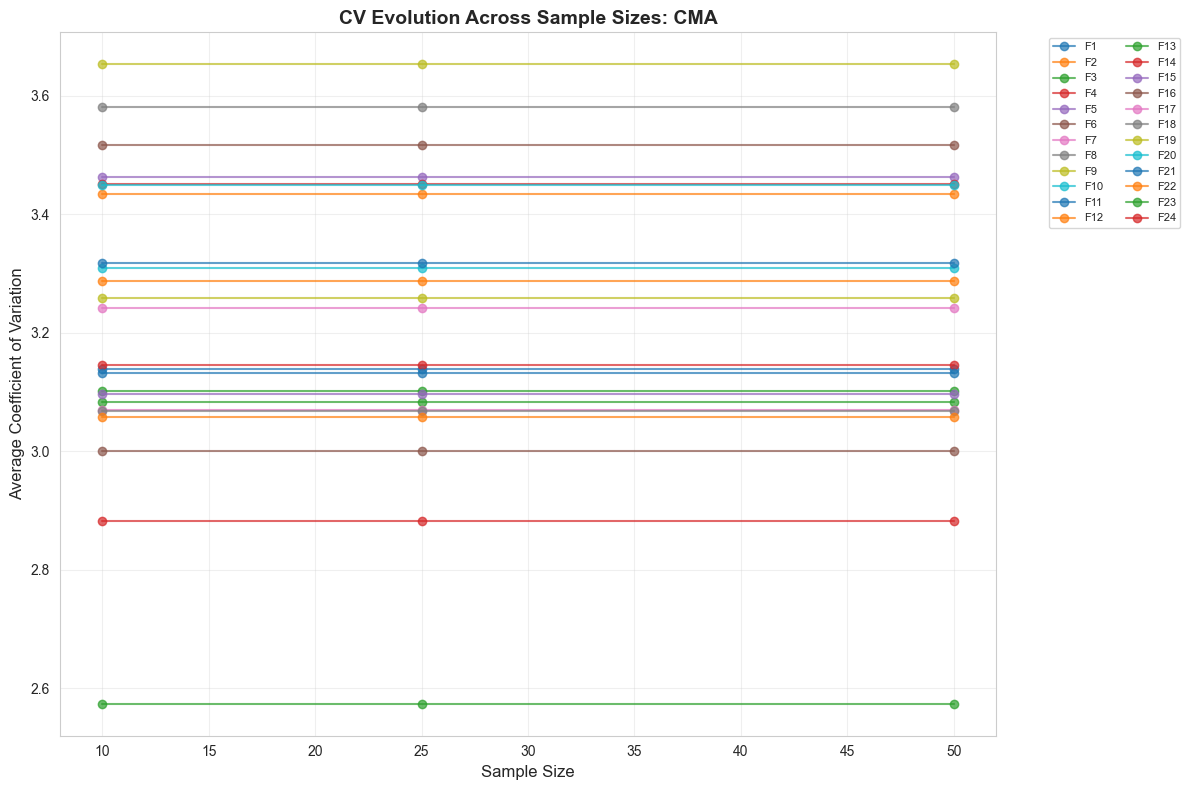

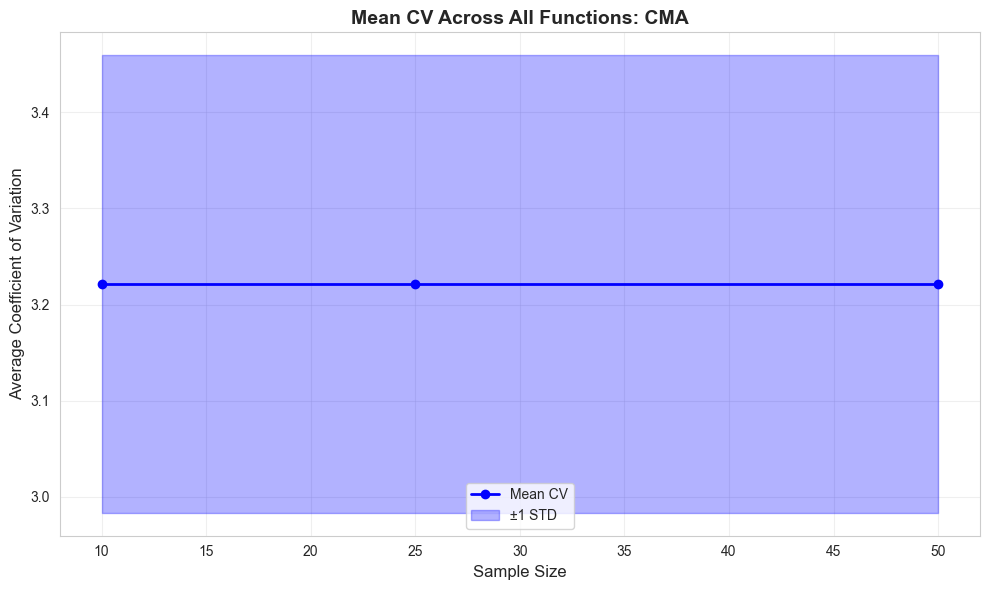

Creating plot for: ilhs


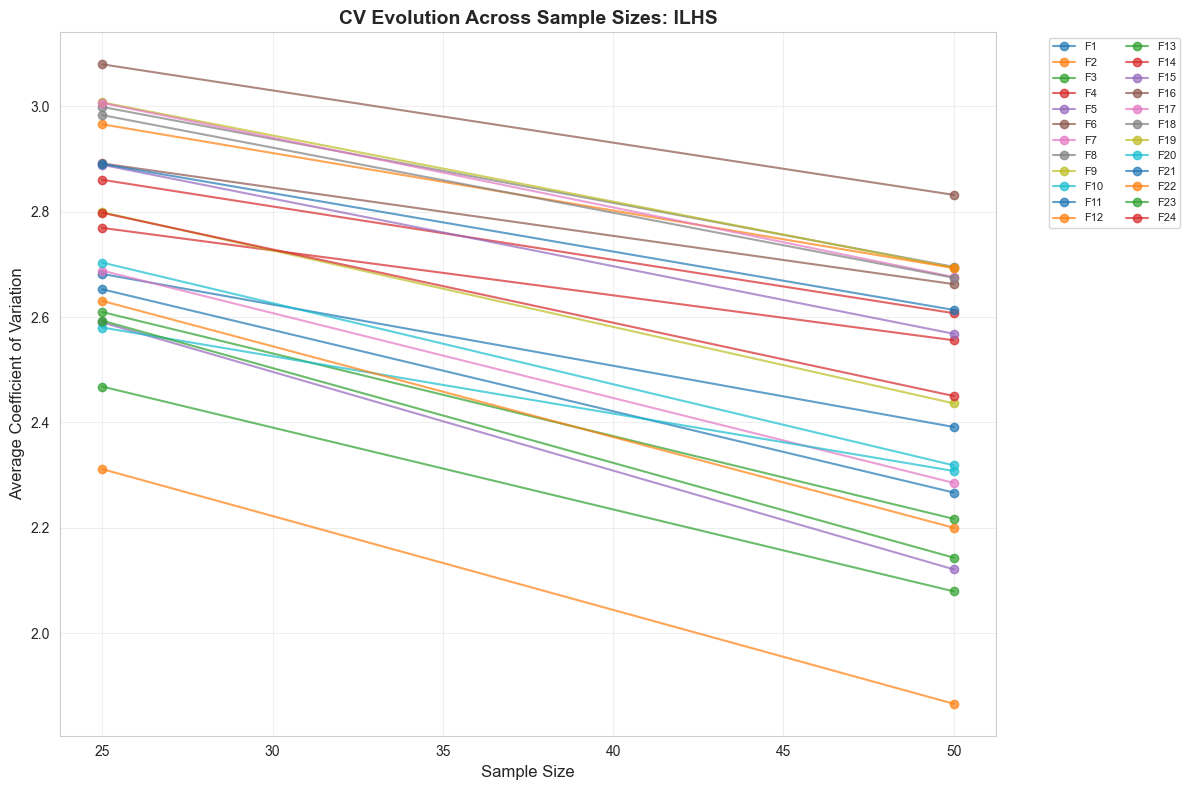

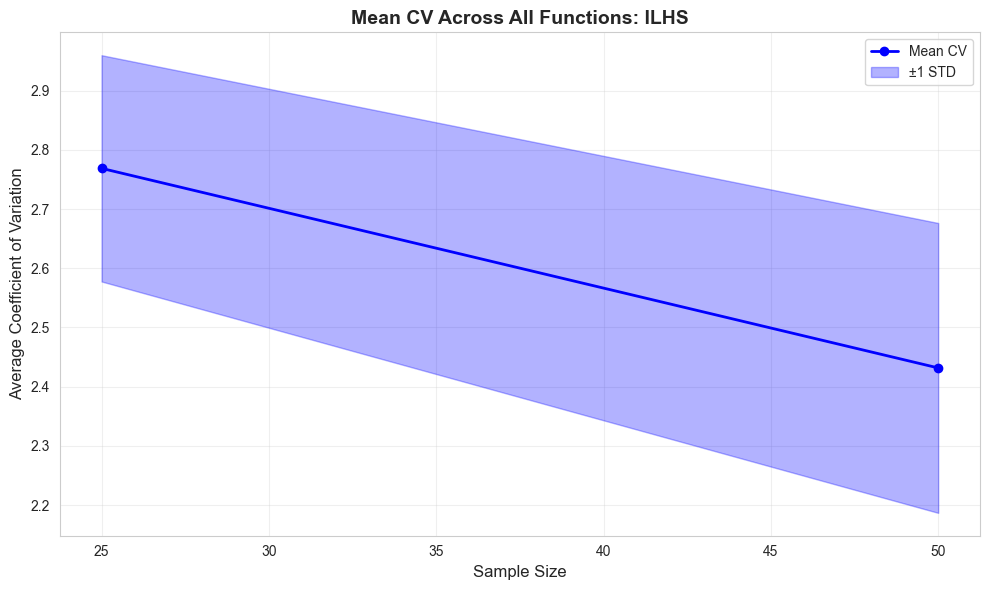

Creating plot for: lhs


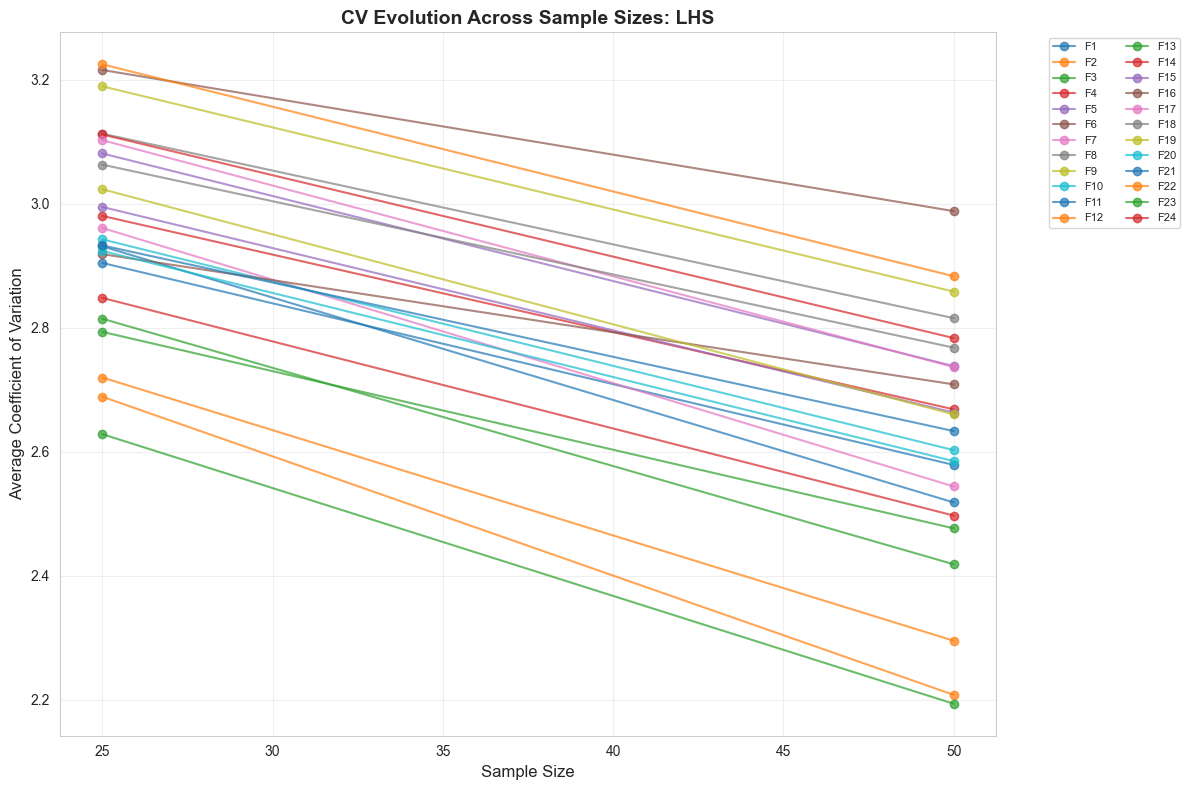

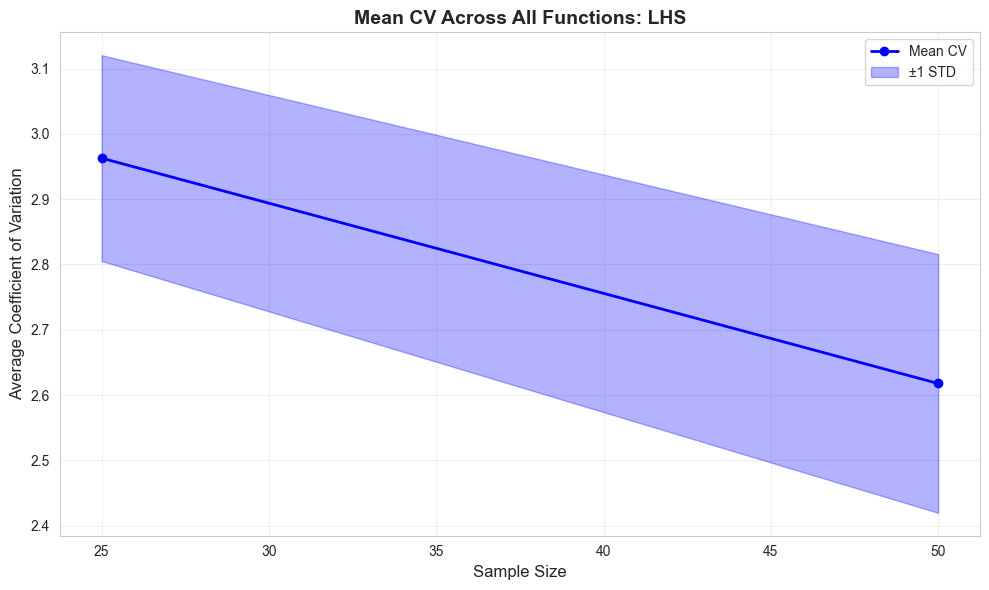

Creating plot for: sobol


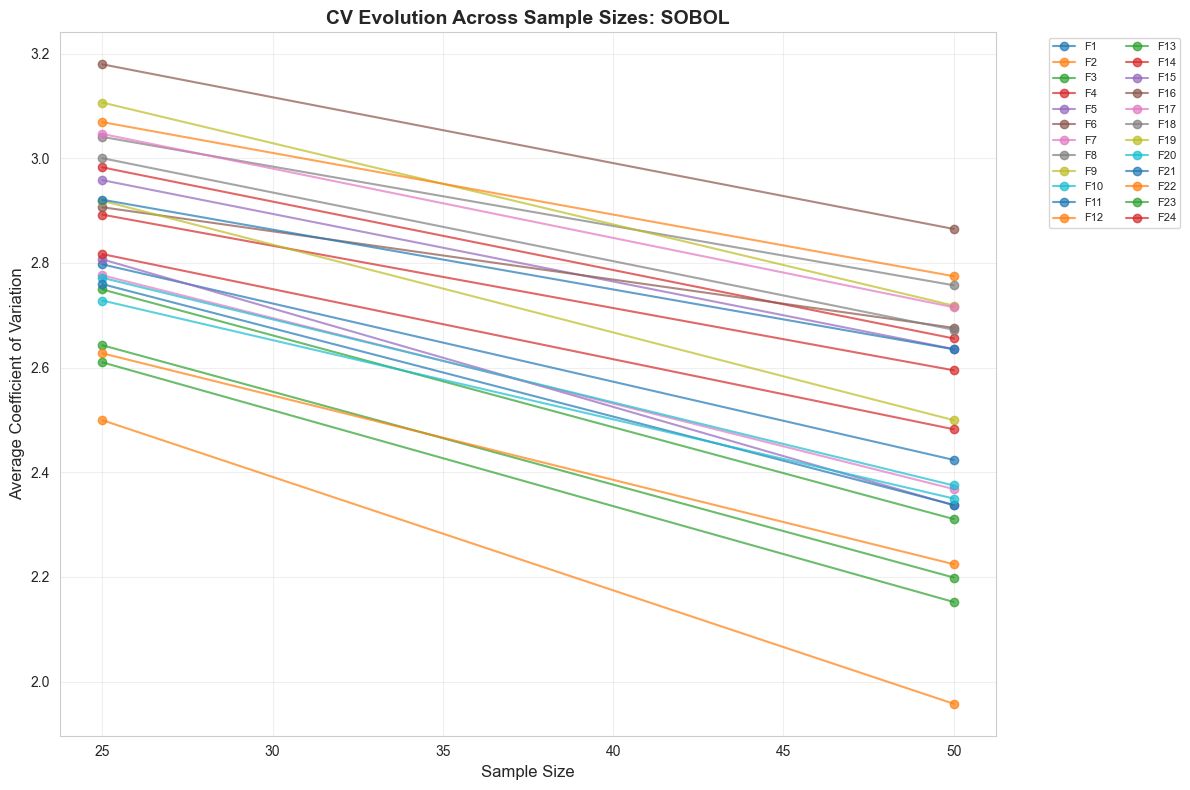

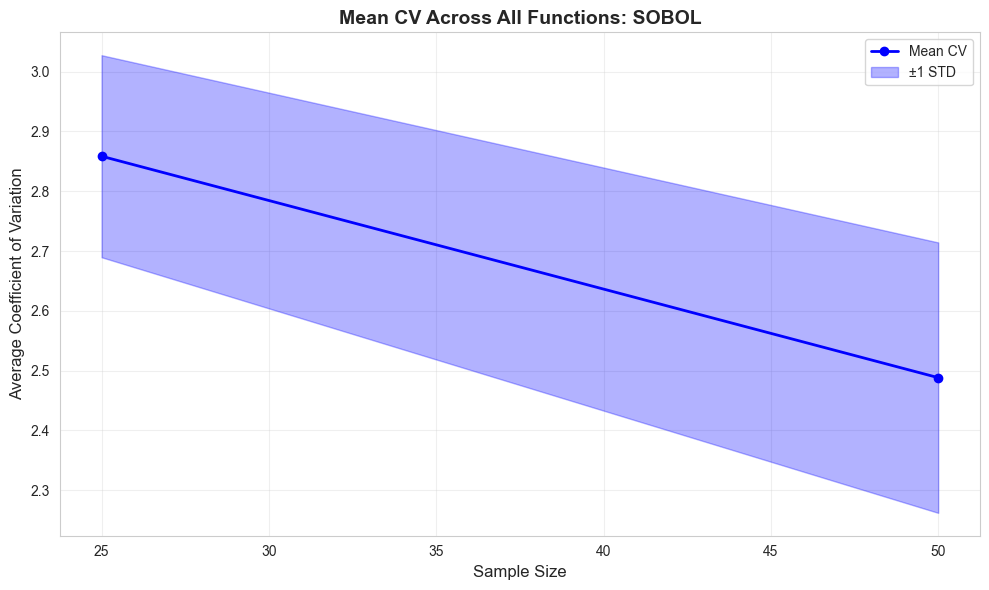

Creating plot for: uniform


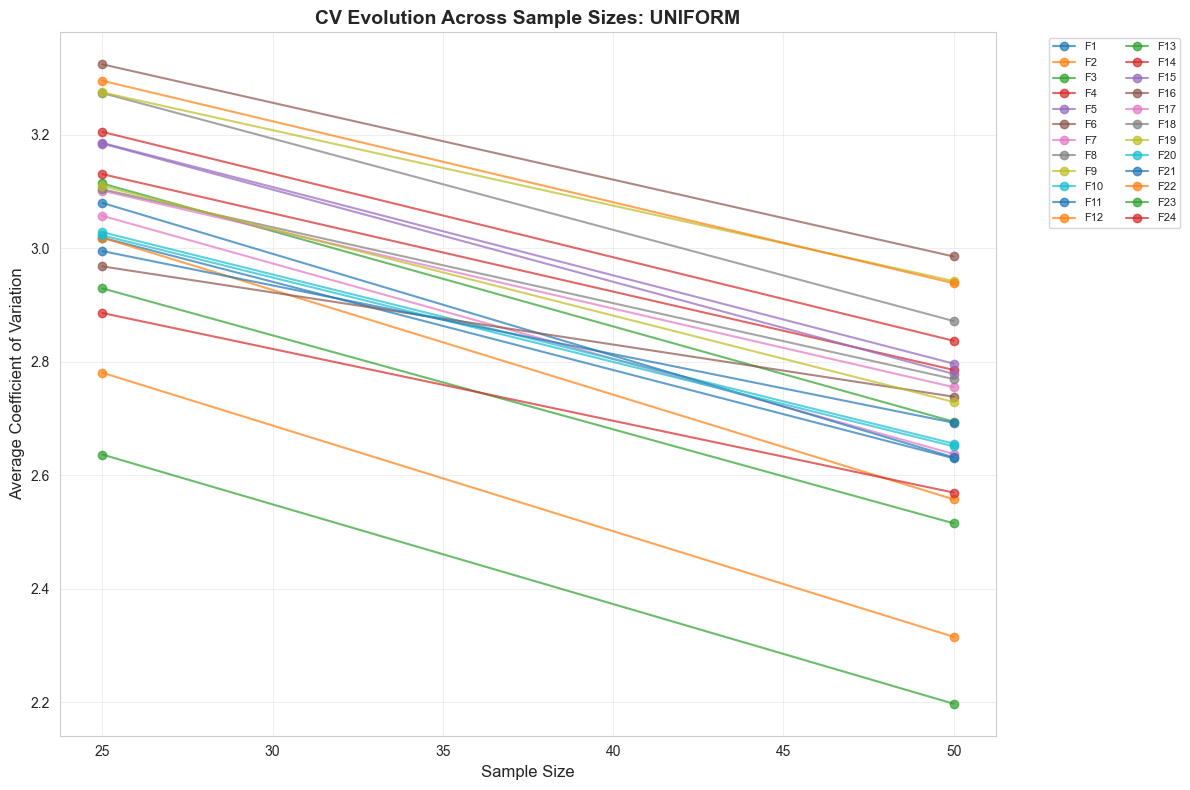

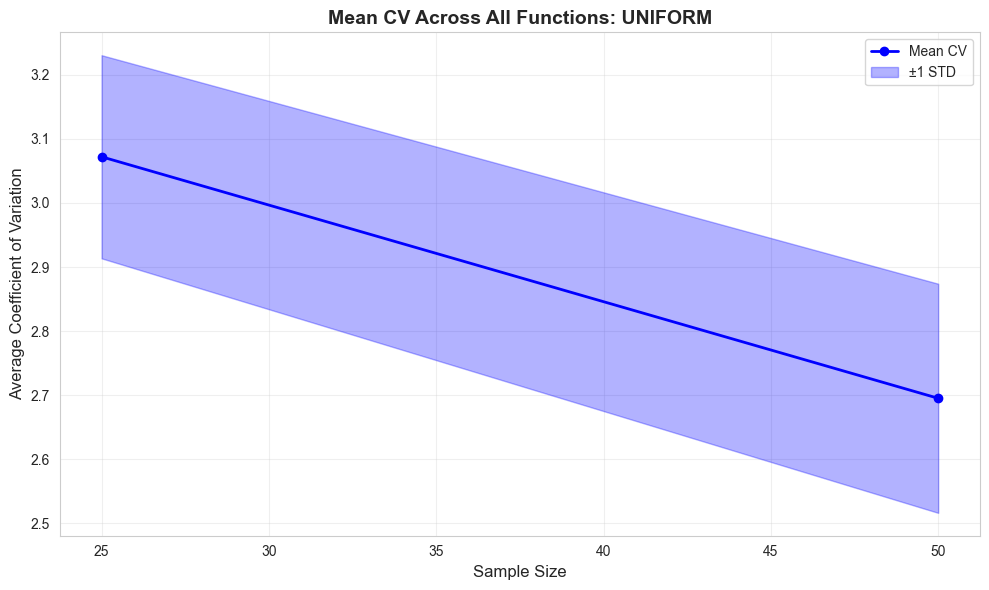

In [52]:
    plot_cv_evolution(cv_data)


In [54]:

def compute_function_avg_cv_by_feature(cv_dict, transform, homology):
    """
    Compute average CV per function for a specific feature.

    Args:
        cv_dict: Dictionary with keys (function, instance, dim)
        transform: 'volume' or 'axis'
        homology: 'h0', 'h1', or 'h2'

    Returns:
        dict: {function_id: avg_cv}
    """
    function_cvs = defaultdict(list)

    for key, transforms in cv_dict.items():
        function, instance, dim = key

        # Check if this specific feature exists
        if transform not in transforms:
            continue
        if transforms[transform][homology] is None:
            continue

        cv_array = transforms[transform][homology]

        # Compute mean CV for this specific configuration
        mean_cv = np.nanmean(cv_array)

        if not np.isnan(mean_cv):
            function_cvs[function].append(mean_cv)

    # Average across all instances for each function
    function_avg = {func: np.mean(cvs) for func, cvs in function_cvs.items()}

    return function_avg


def plot_cv_evolution_by_feature(cv_data):
    """
    Create plots showing CV evolution across sample sizes for each technique and feature.

    Args:
        cv_data: Loaded CV dictionary
        output_dir: Directory to save plots
    """

    # Define features to plot
    transforms = ['volume', 'axis']
    homologies = ['h0', 'h1', 'h2']

    # Organize data by technique
    for transform in transforms:
        for homology in homologies:
            print(f"\nProcessing {transform}/{homology}...")

            technique_data = defaultdict(lambda: defaultdict(dict))

            for key_name, cv_dict in cv_data.items():
                technique, sample_size = parse_key(key_name)

                # Compute average CV per function for this specific feature
                function_avg_cv = compute_function_avg_cv_by_feature(
                    cv_dict, transform, homology
                )

                technique_data[technique][sample_size] = function_avg_cv

            # Create a plot for each sampling technique
            for technique, sample_size_data in technique_data.items():
                if not sample_size_data:
                    continue

                print(f"  Creating plot for: {technique} - {transform}/{homology}")

                # Get all sample sizes and sort them
                sample_sizes = sorted(sample_size_data.keys())

                # Get all functions (should be 1-24)
                all_functions = set()
                for func_dict in sample_size_data.values():
                    all_functions.update(func_dict.keys())
                all_functions = sorted(all_functions)

                # Create the plot with individual function lines
                fig, ax = plt.subplots(figsize=(12, 8))

                # Plot a line for each function
                for function in all_functions:
                    cvs = []
                    sizes = []

                    for sample_size in sample_sizes:
                        if function in sample_size_data[sample_size]:
                            cvs.append(sample_size_data[sample_size][function])
                            sizes.append(sample_size)

                    if cvs:  # Only plot if we have data
                        ax.plot(sizes, cvs, marker='o', label=f'F{function}', alpha=0.7)

                ax.set_xlabel('Sample Size', fontsize=12)
                ax.set_ylabel('Average Coefficient of Variation', fontsize=12)
                ax.set_title(f'CV Evolution: {technique.upper()} - {transform}/{homology}',
                             fontsize=14, fontweight='bold')
                ax.grid(True, alpha=0.3)

                # Add legend
                ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
                         ncol=2, fontsize=8)

                plt.tight_layout()

                plt.show()
                plt.close()

                # Also create a summary plot with mean and std across all functions
                fig, ax = plt.subplots(figsize=(10, 6))

                mean_cvs = []
                std_cvs = []

                for sample_size in sample_sizes:
                    func_cvs = list(sample_size_data[sample_size].values())
                    if func_cvs:
                        mean_cvs.append(np.mean(func_cvs))
                        std_cvs.append(np.std(func_cvs))

                if mean_cvs:
                    mean_cvs = np.array(mean_cvs)
                    std_cvs = np.array(std_cvs)

                    ax.plot(sample_sizes, mean_cvs, marker='o', linewidth=2,
                            label='Mean CV', color='blue')
                    ax.fill_between(sample_sizes,
                                    mean_cvs - std_cvs,
                                    mean_cvs + std_cvs,
                                    alpha=0.3, color='blue', label='±1 STD')

                ax.set_xlabel('Sample Size', fontsize=12)
                ax.set_ylabel('Average Coefficient of Variation', fontsize=12)
                ax.set_title(f'Mean CV: {technique.upper()} - {transform}/{homology}',
                             fontsize=14, fontweight='bold')
                ax.grid(True, alpha=0.3)
                ax.legend()

                plt.tight_layout()

                plt.show()
                plt.close()


def plot_overall_comparison(cv_data):
    """
    Create comparison plots showing all features together for each technique.

    Args:
        cv_data: Loaded CV dictionary
        output_dir: Directory to save plots
    """
    print(f"\nCreating overall comparison plots...")

    transforms = ['volume', 'axis']
    homologies = ['h0', 'h1', 'h2']

    # Organize data by technique
    technique_data = defaultdict(lambda: defaultdict(lambda: defaultdict(dict)))

    for key_name, cv_dict in cv_data.items():
        technique, sample_size = parse_key(key_name)

        for transform in transforms:
            for homology in homologies:
                function_avg_cv = compute_function_avg_cv_by_feature(
                    cv_dict, transform, homology
                )

                if function_avg_cv:
                    # Store mean across all functions
                    mean_cv = np.mean(list(function_avg_cv.values()))
                    technique_data[technique][sample_size][f"{transform}_{homology}"] = mean_cv

    # Create a plot for each technique showing all features
    for technique, sample_size_data in technique_data.items():
        print(f"  Creating comparison plot for: {technique}")

        sample_sizes = sorted(sample_size_data.keys())

        fig, ax = plt.subplots(figsize=(12, 8))

        # Plot each feature combination
        for transform in transforms:
            for homology in homologies:
                feature_key = f"{transform}_{homology}"
                cvs = []

                for sample_size in sample_sizes:
                    if feature_key in sample_size_data[sample_size]:
                        cvs.append(sample_size_data[sample_size][feature_key])
                    else:
                        cvs.append(np.nan)

                if not all(np.isnan(cvs)):
                    ax.plot(sample_sizes, cvs, marker='o', linewidth=2,
                           label=f'{transform}/{homology}', alpha=0.8)

        ax.set_xlabel('Sample Size', fontsize=12)
        ax.set_ylabel('Average Coefficient of Variation', fontsize=12)
        ax.set_title(f'CV Evolution by Feature Type: {technique.upper()}',
                     fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend()

        plt.tight_layout()

        plt.show()
        plt.close()


Processing volume/h0...
  Creating plot for: cma - volume/h0


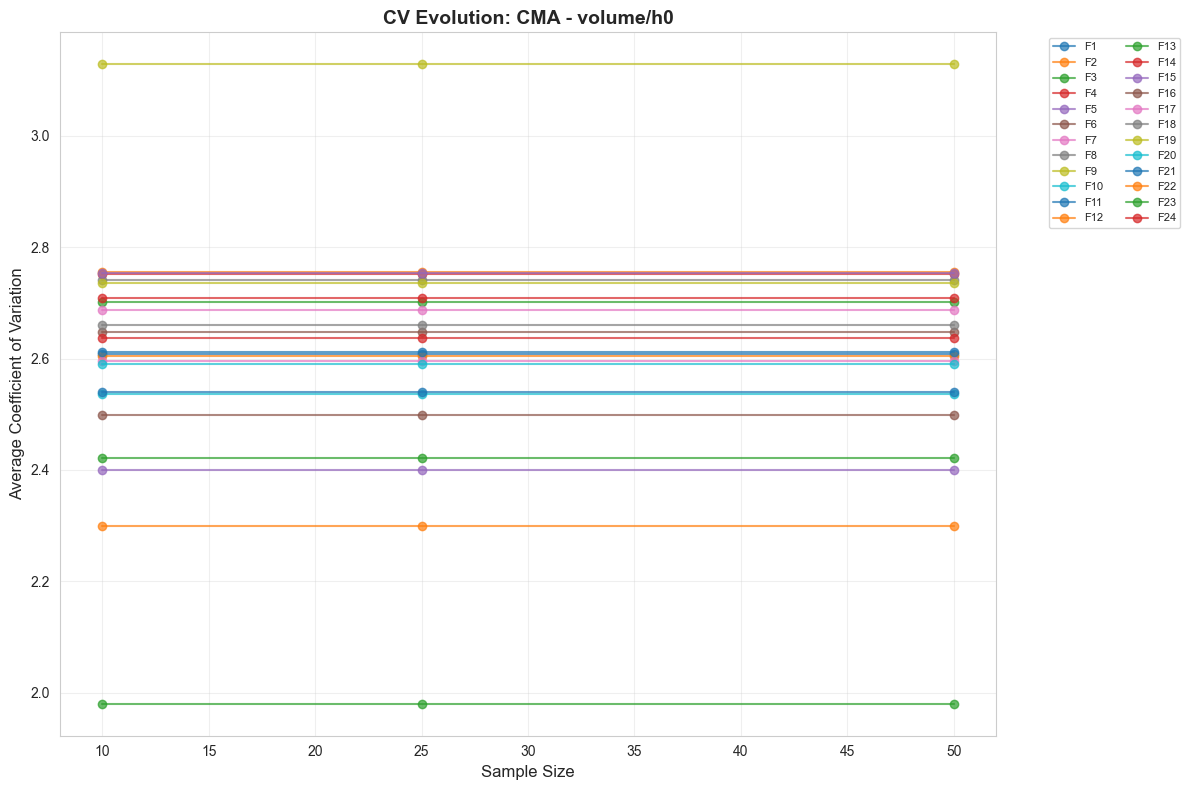

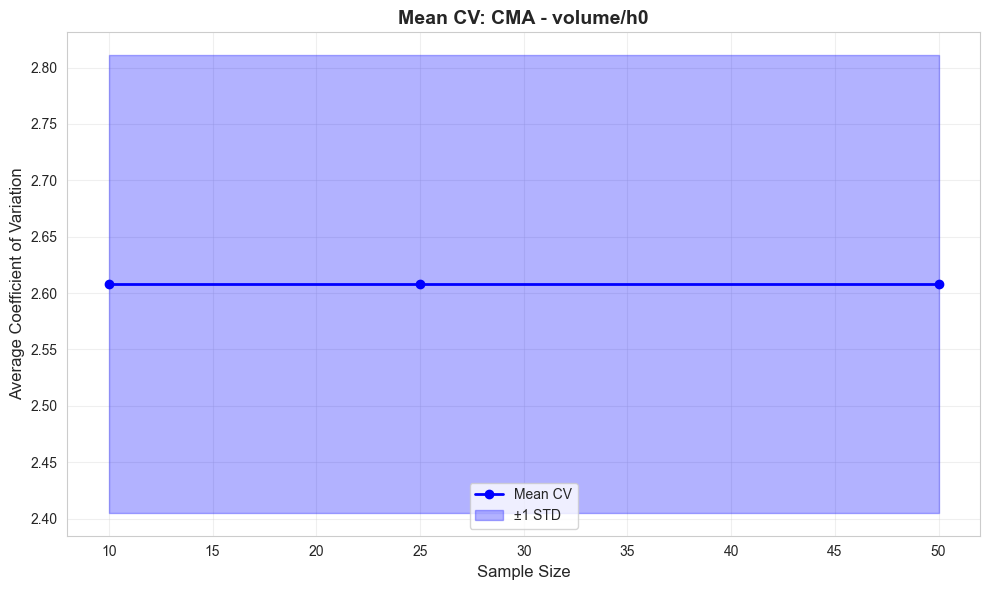

  Creating plot for: ilhs - volume/h0


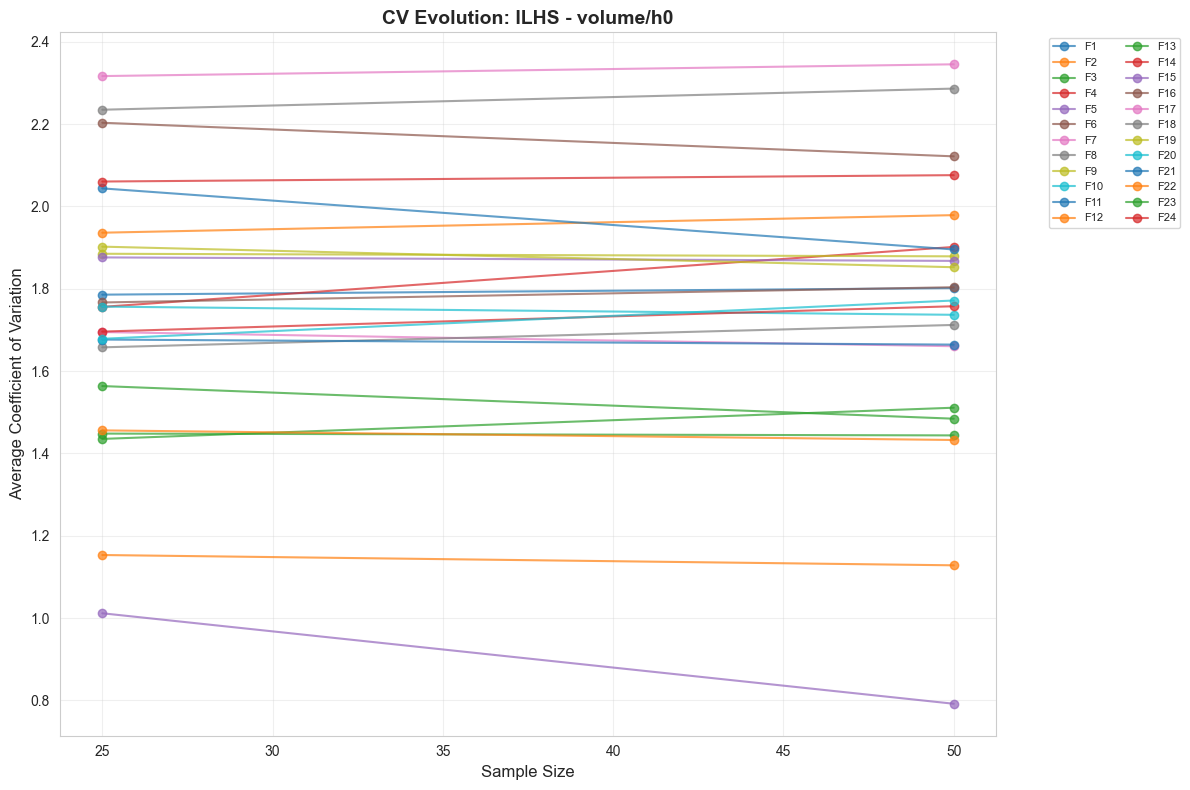

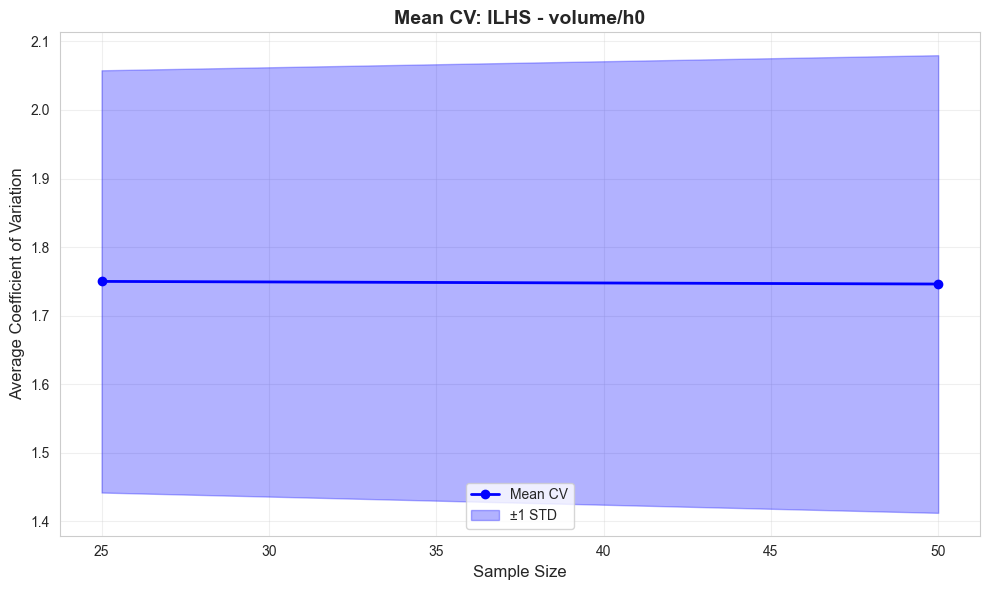

  Creating plot for: lhs - volume/h0


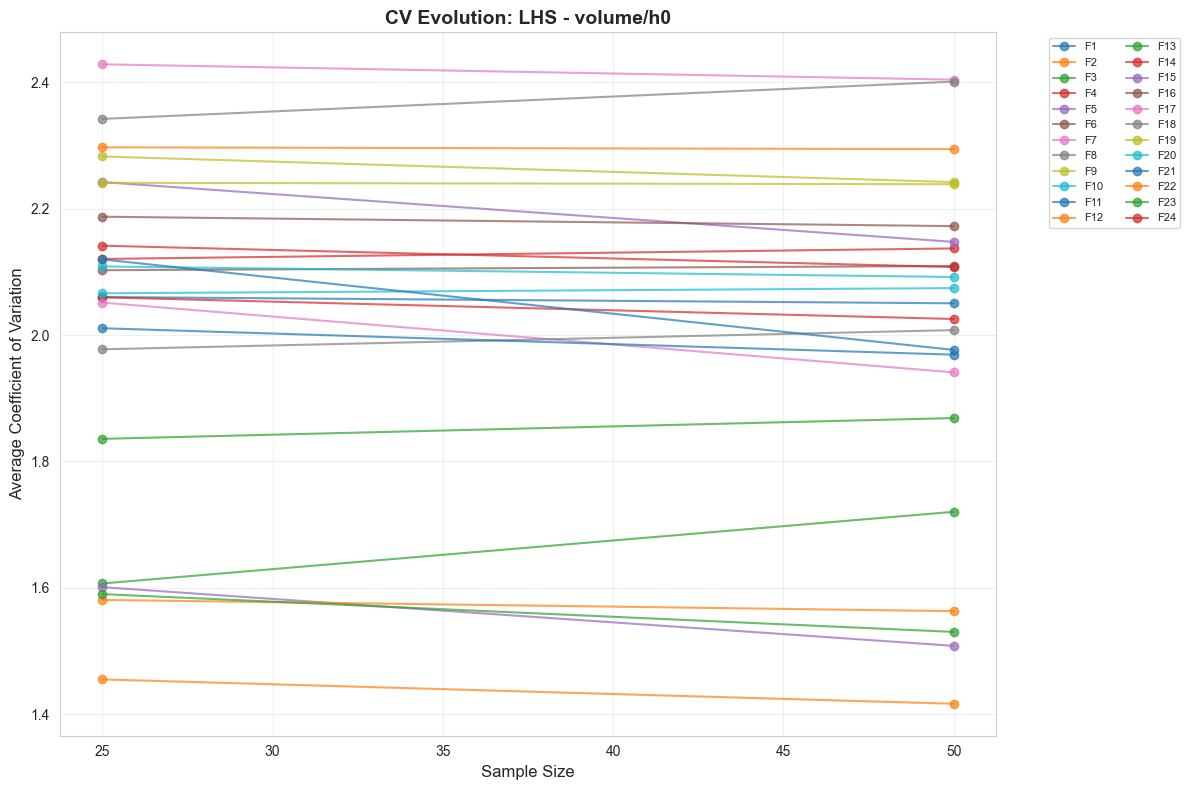

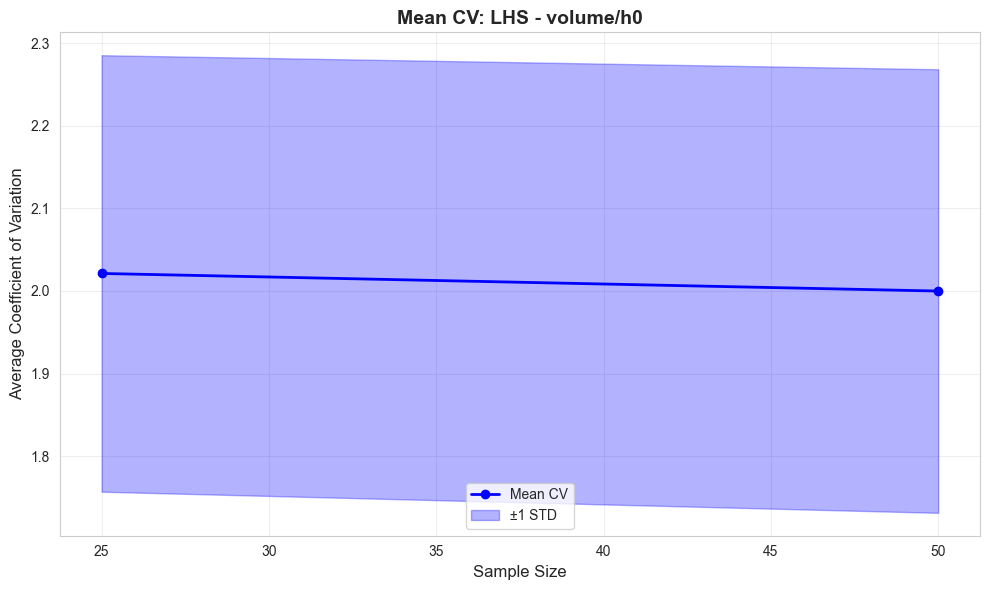

  Creating plot for: sobol - volume/h0


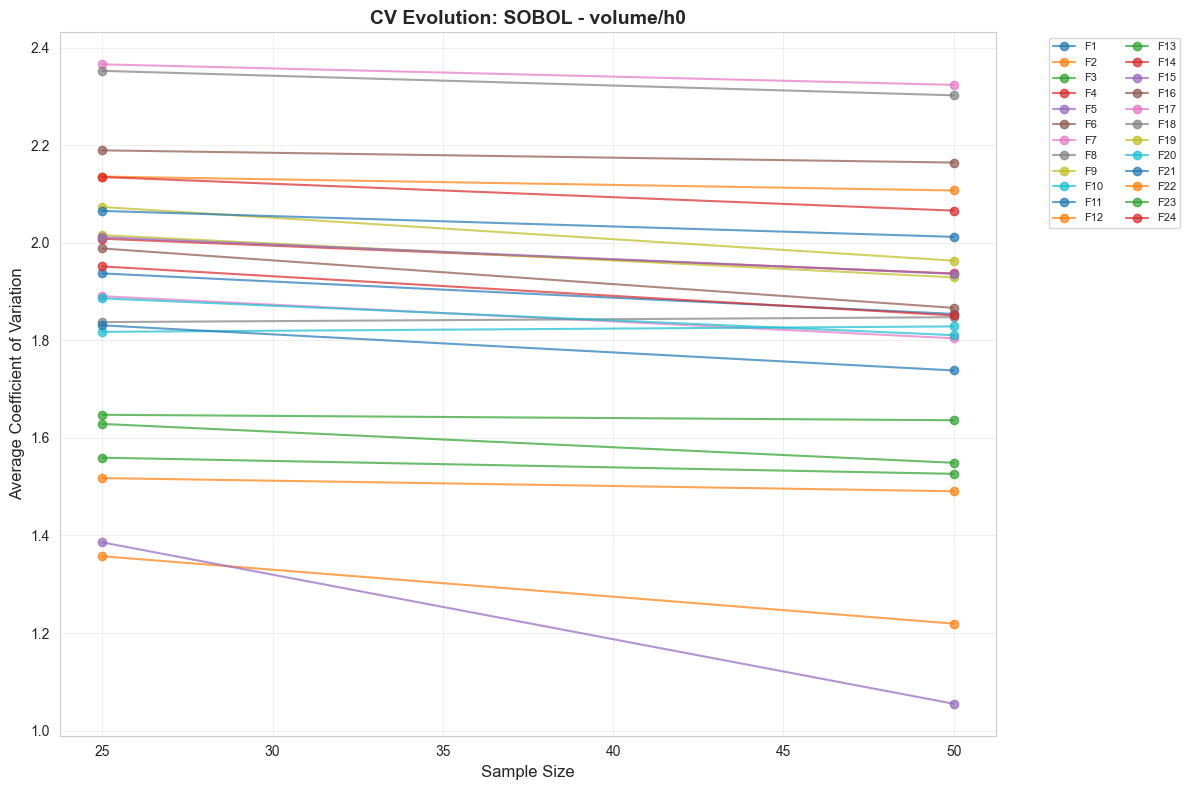

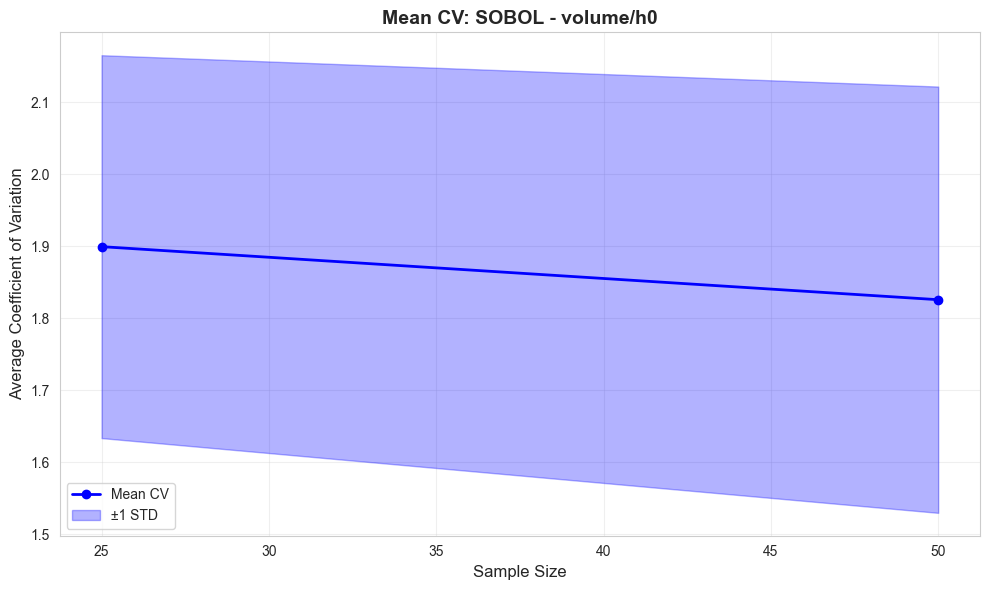

  Creating plot for: uniform - volume/h0


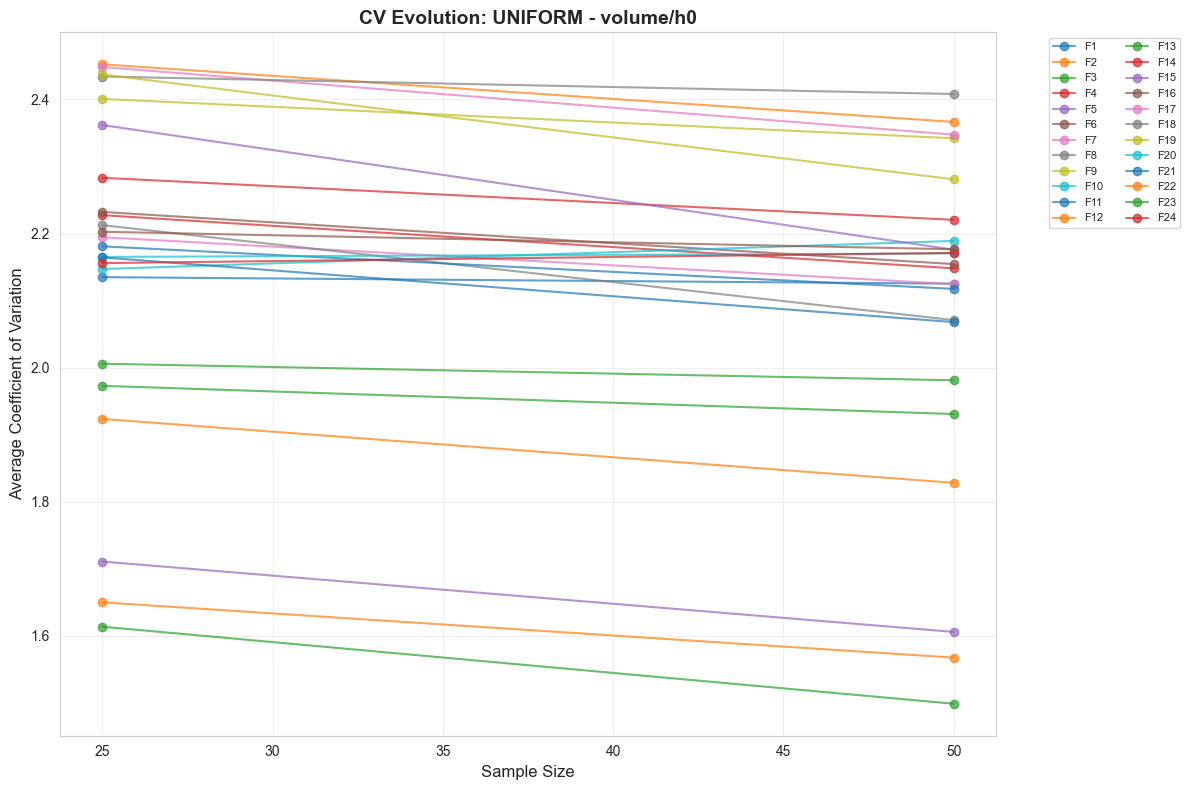

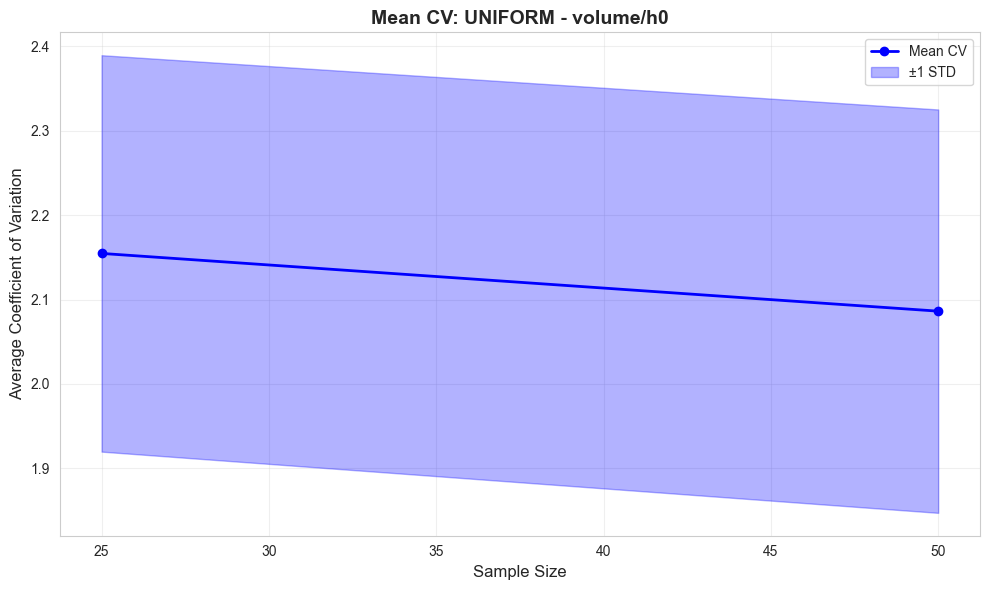


Processing volume/h1...
  Creating plot for: cma - volume/h1


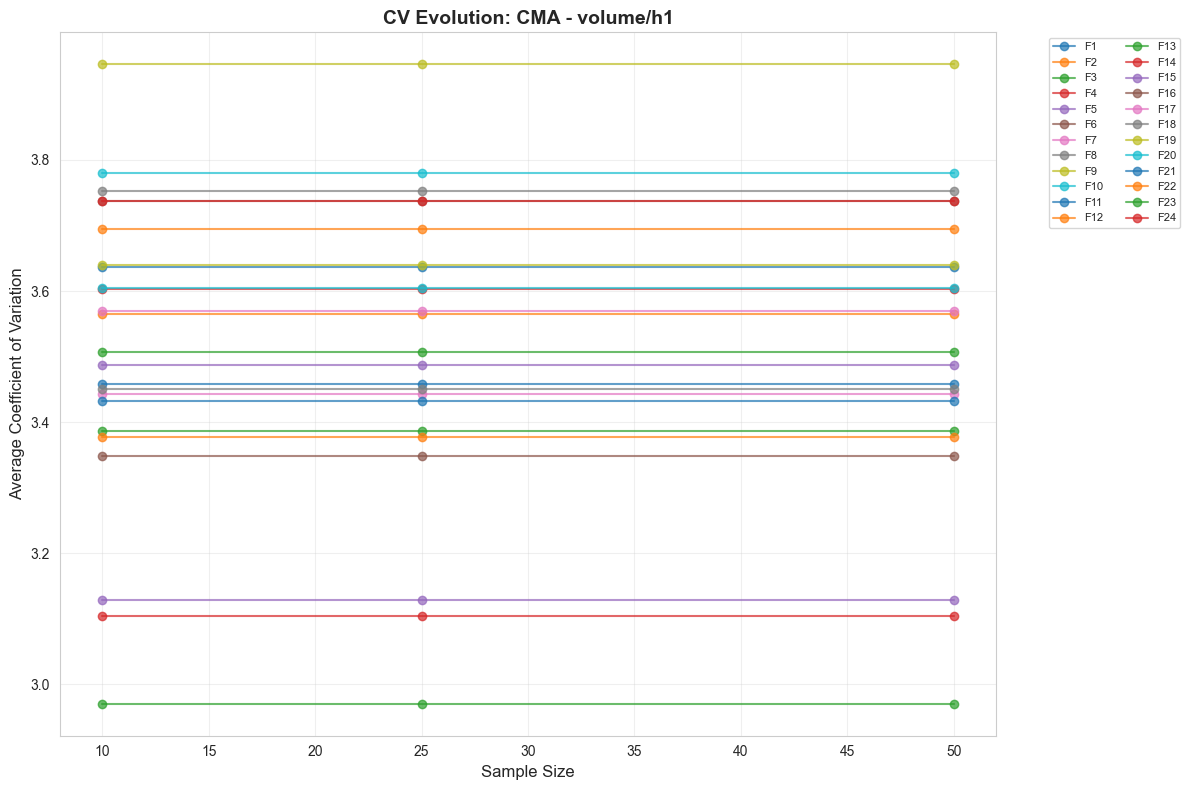

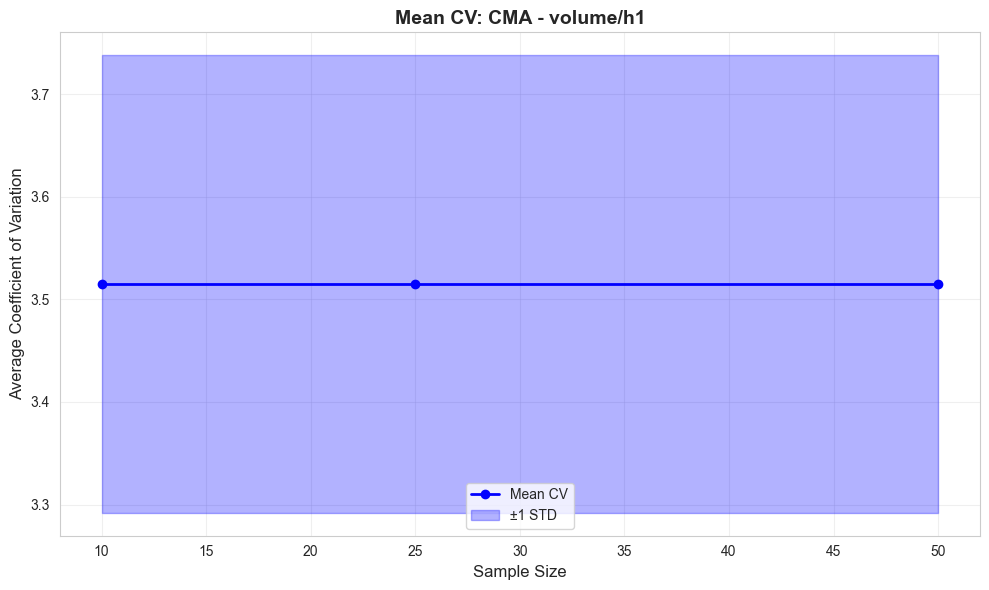

  Creating plot for: ilhs - volume/h1


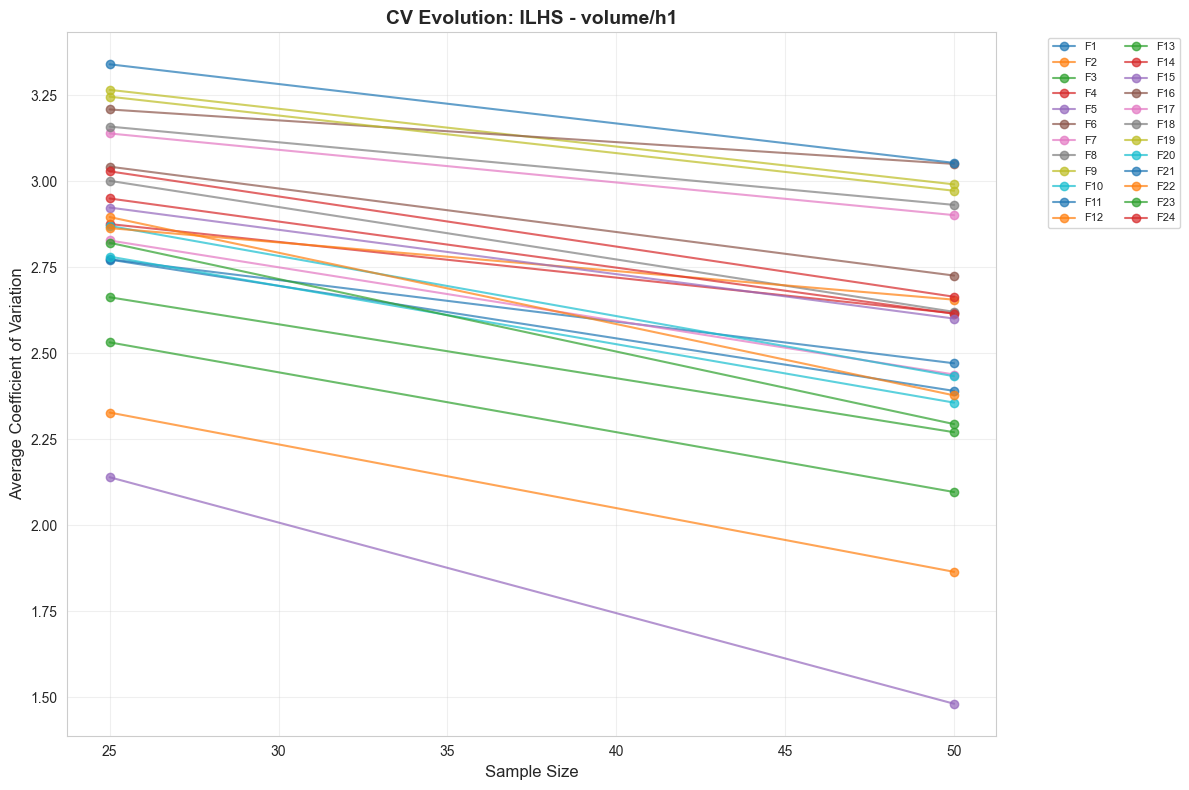

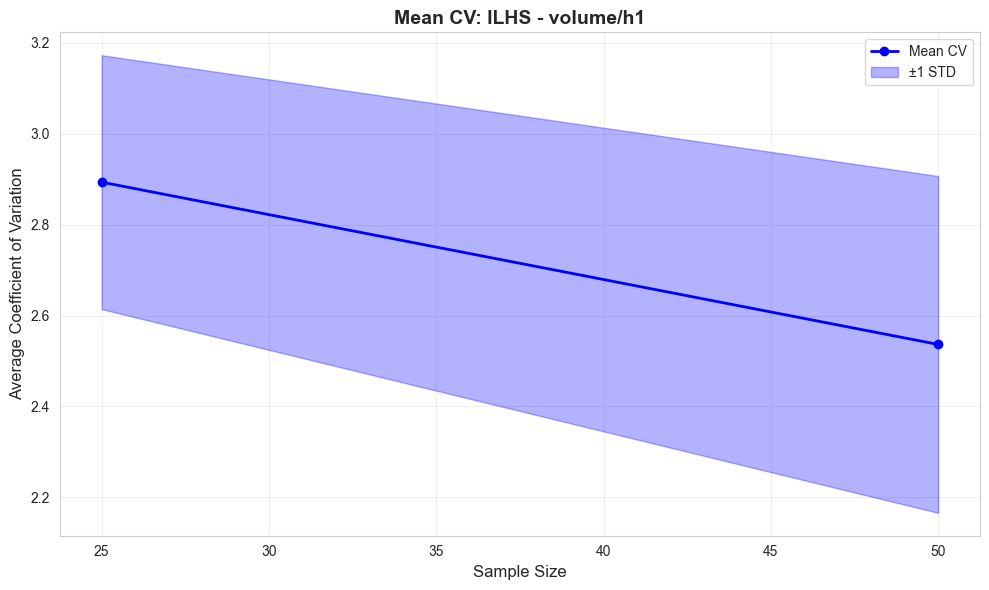

  Creating plot for: lhs - volume/h1


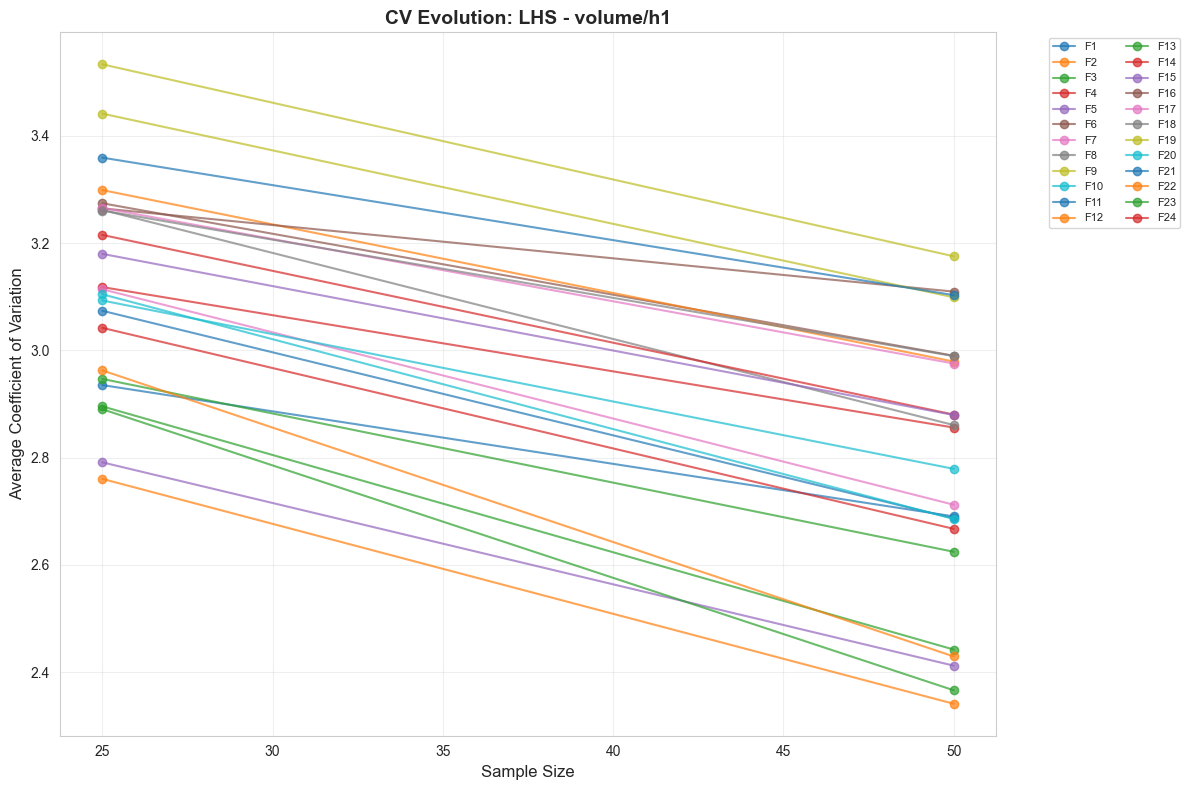

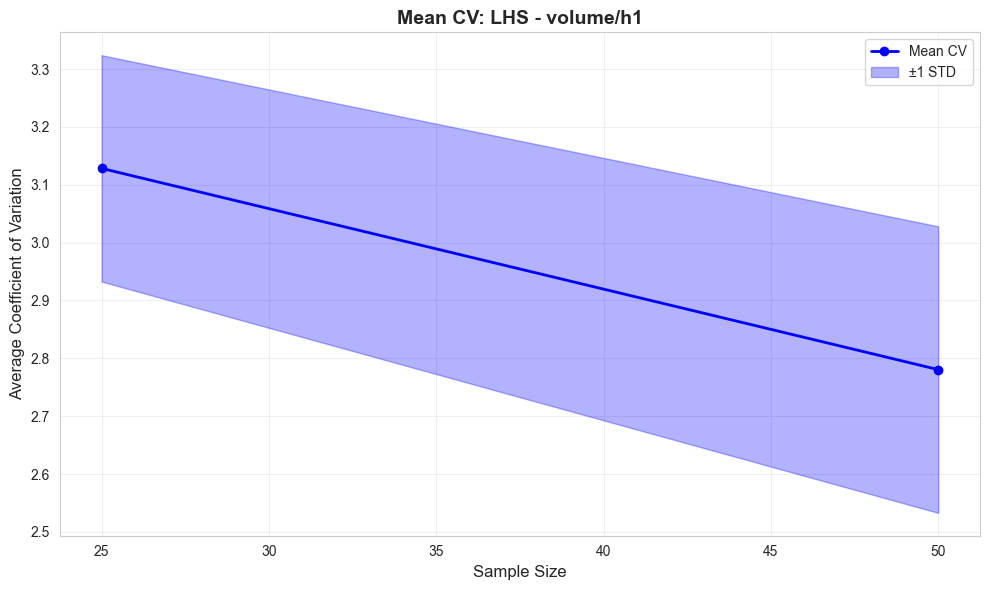

  Creating plot for: sobol - volume/h1


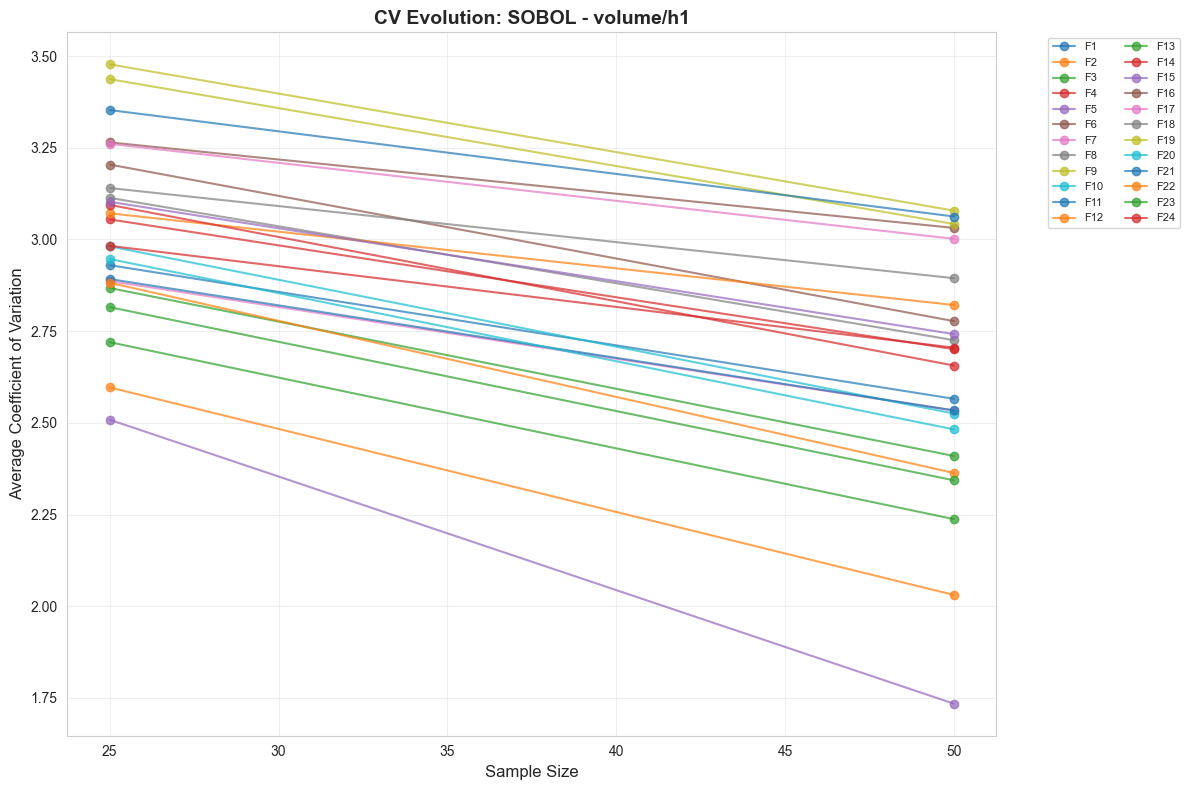

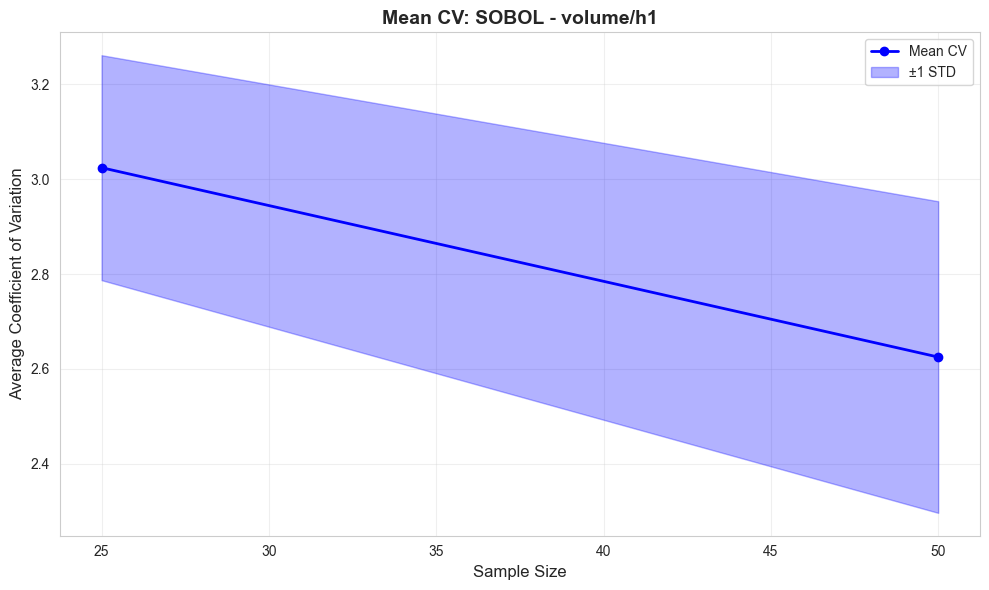

  Creating plot for: uniform - volume/h1


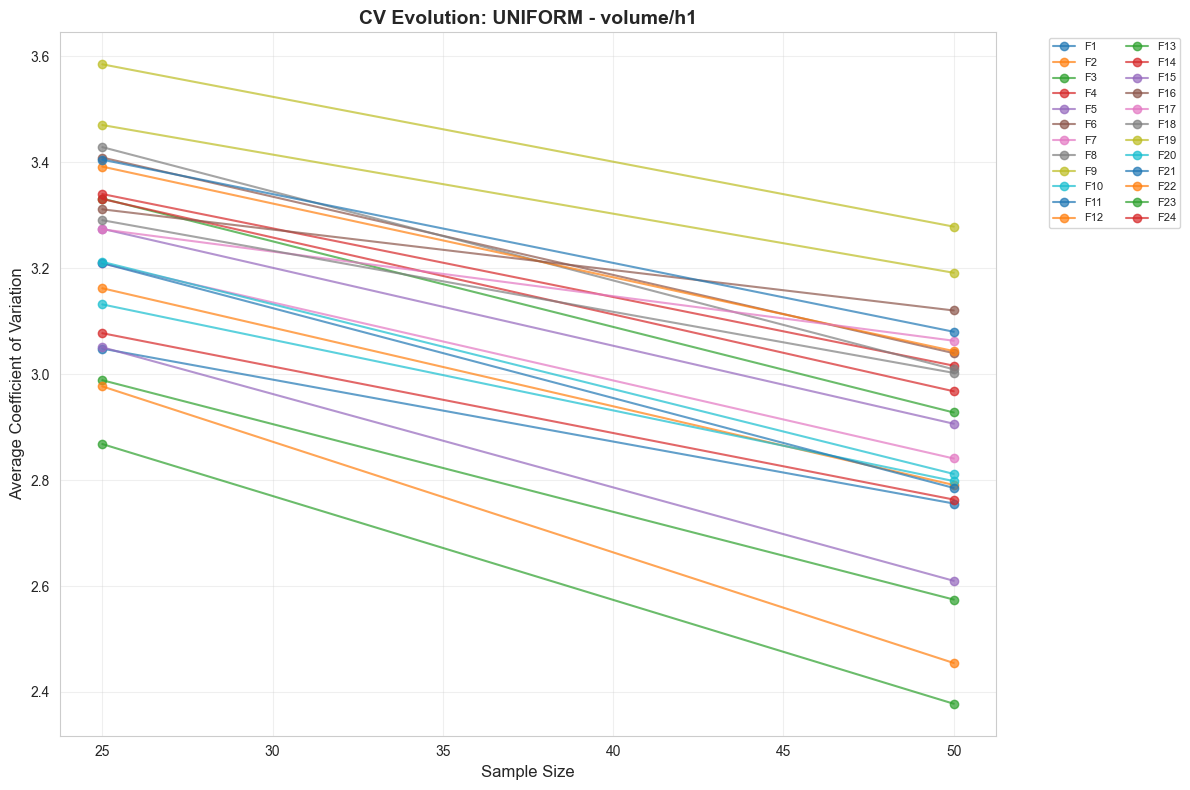

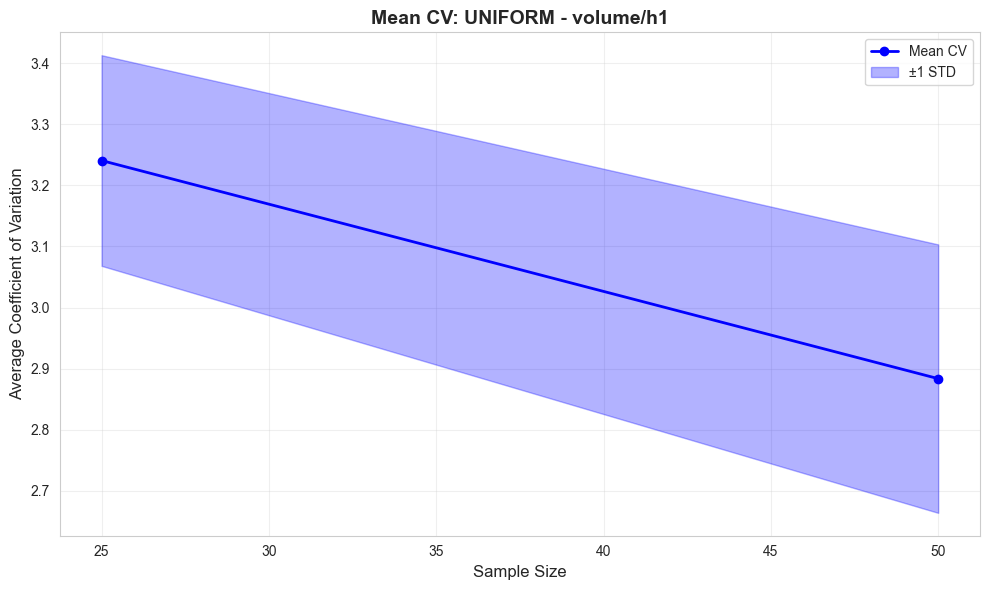


Processing volume/h2...


/var/folders/2x/yr46rn912_91htch_br0s2x80000gn/T/ipykernel_24186/1116243346.py:27: RuntimeWarning: Mean of empty slice
  mean_cv = np.nanmean(cv_array)


  Creating plot for: cma - volume/h2


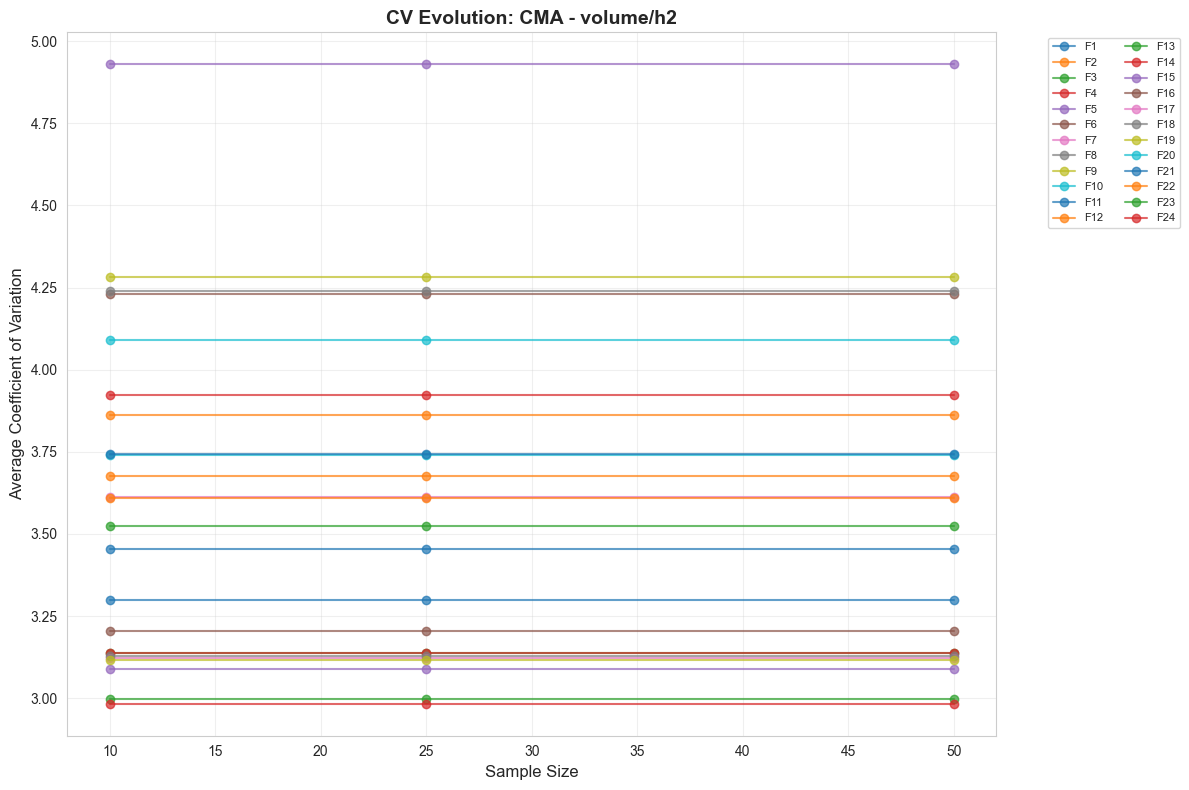

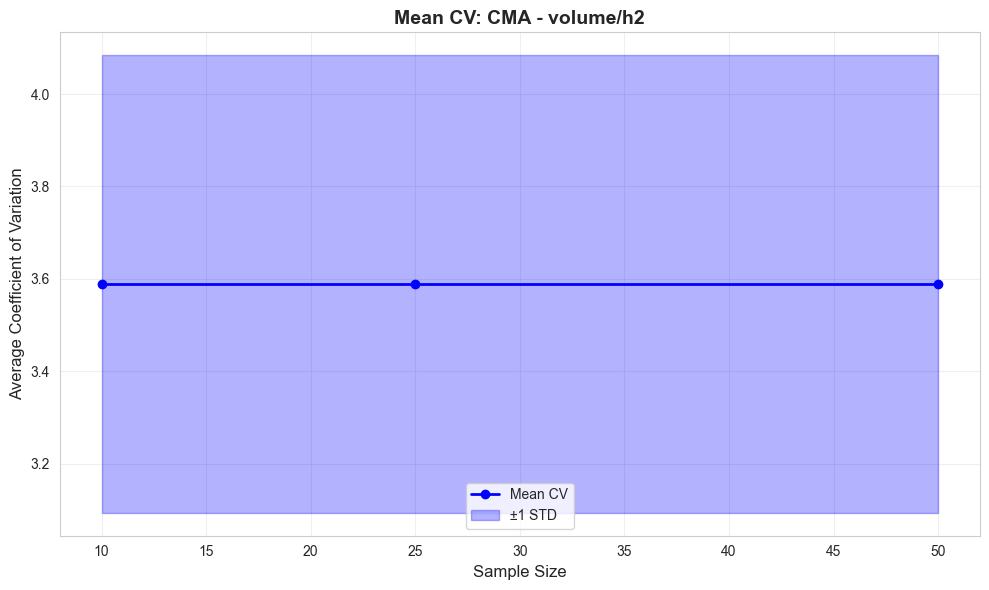

  Creating plot for: ilhs - volume/h2


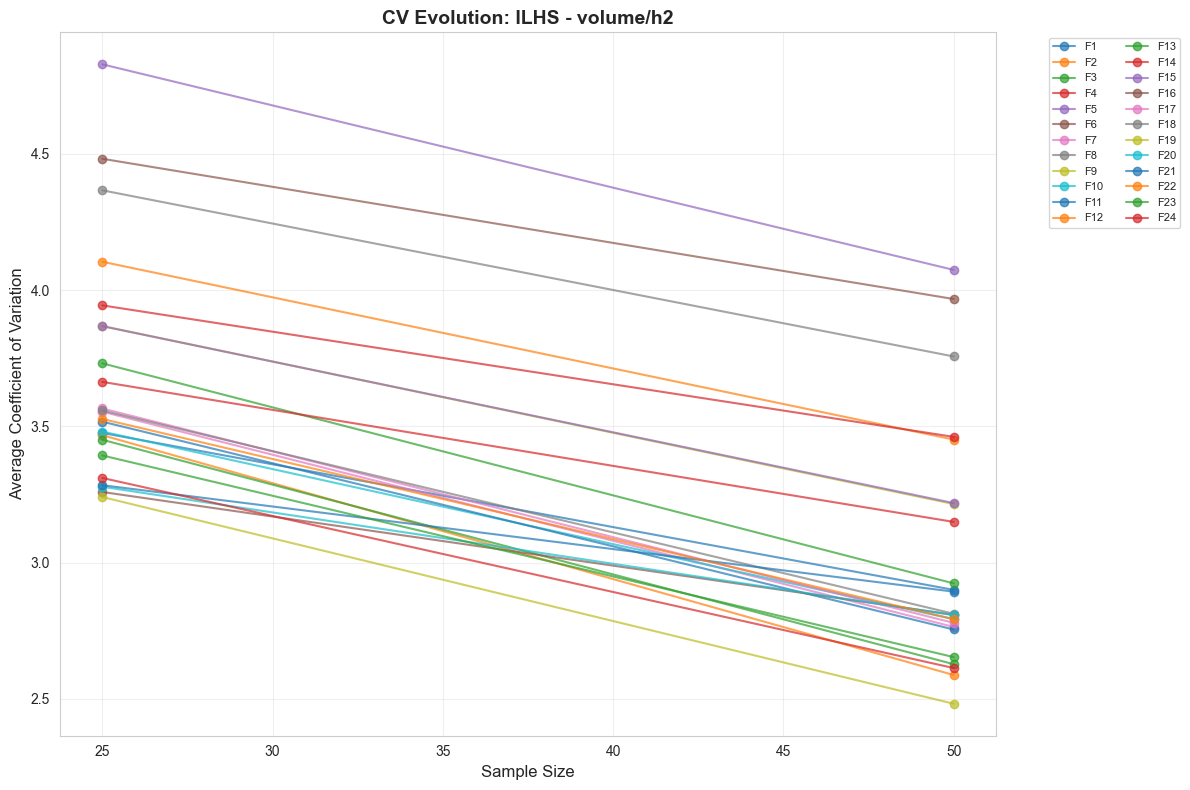

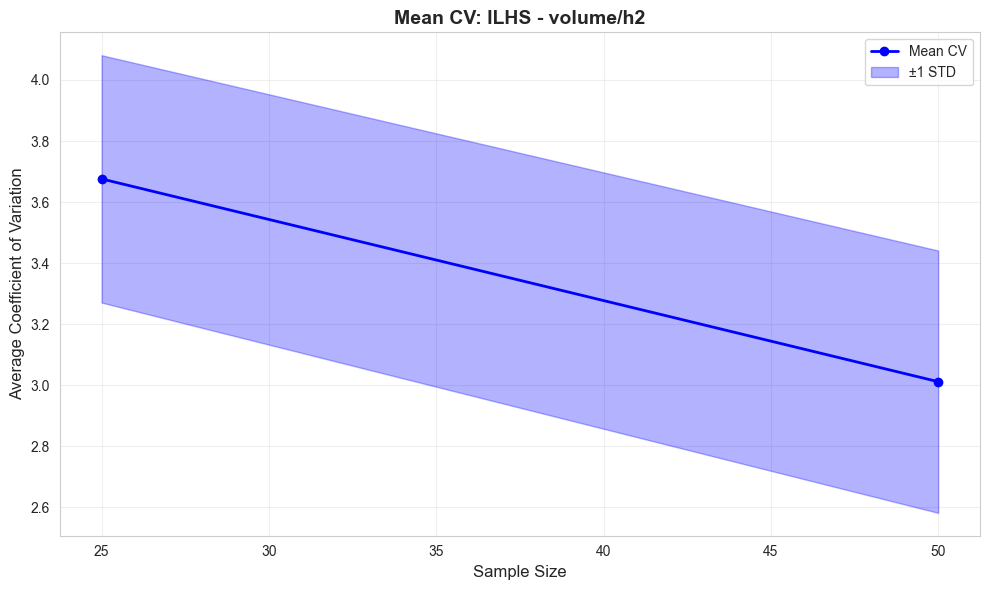

  Creating plot for: lhs - volume/h2


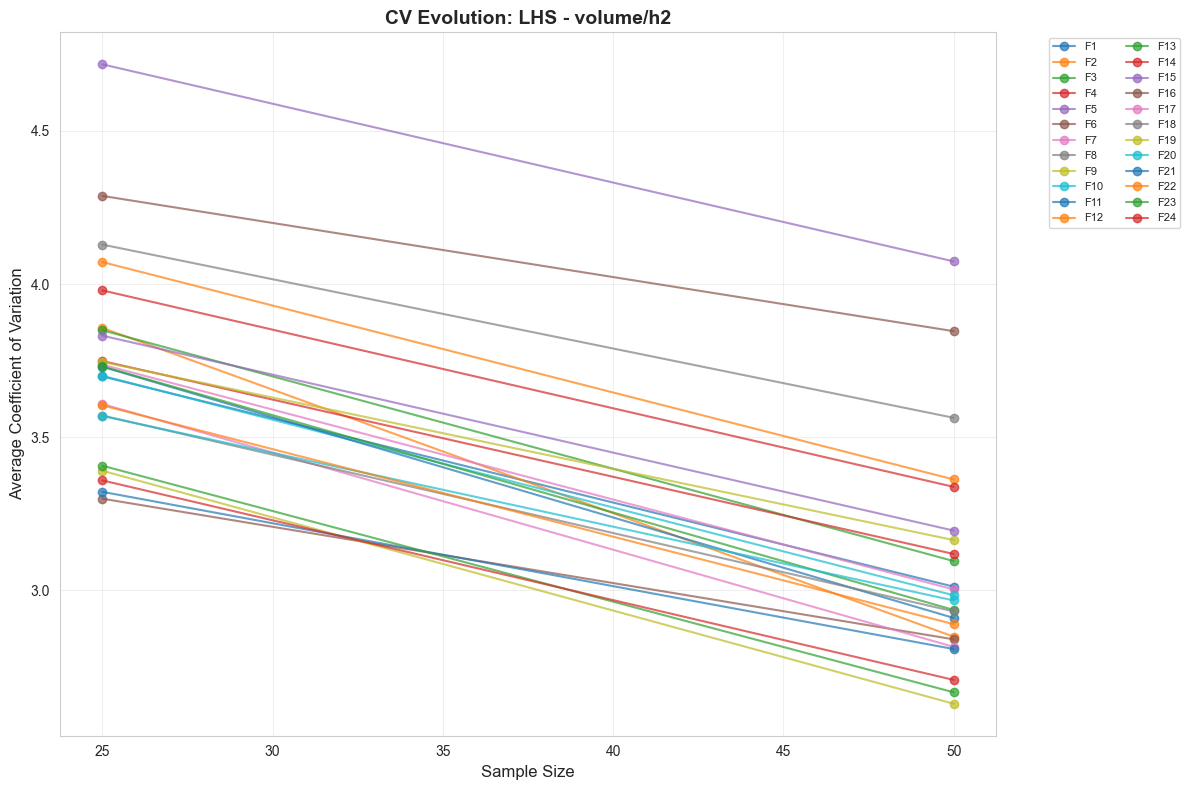

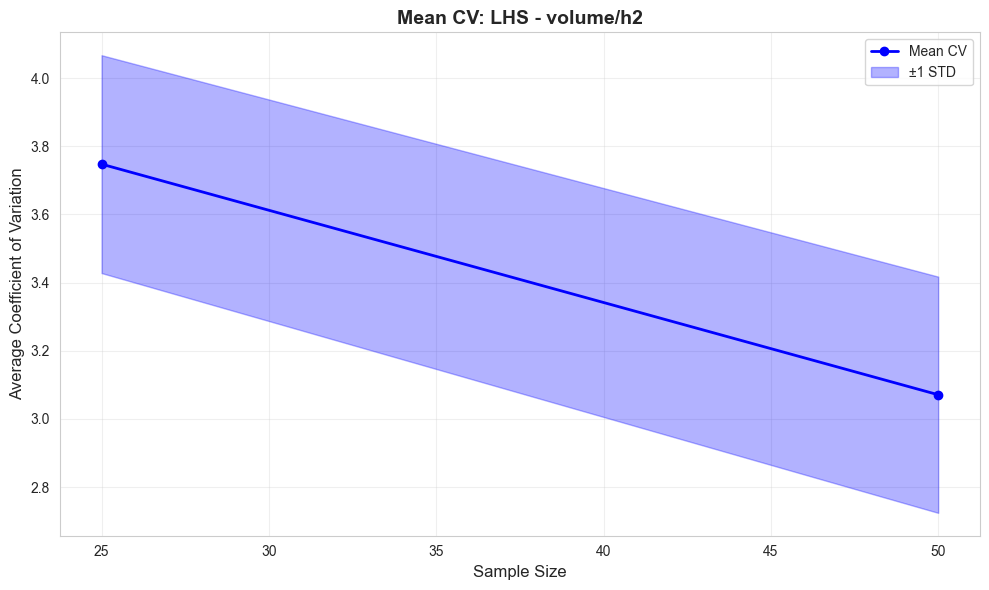

  Creating plot for: sobol - volume/h2


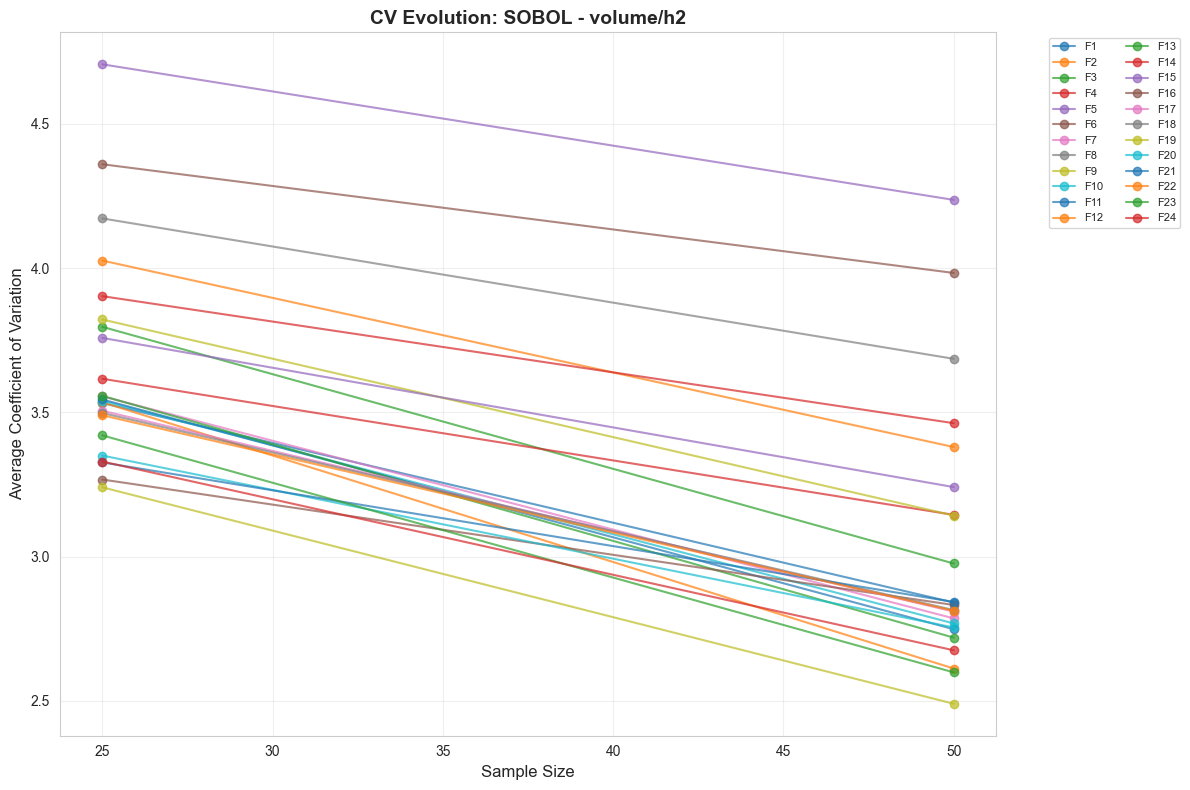

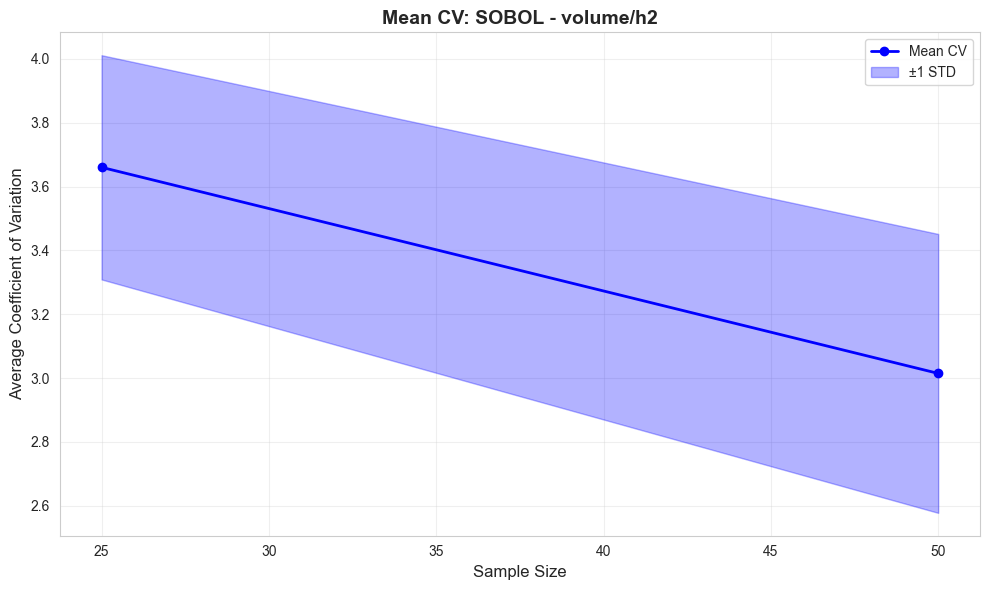

  Creating plot for: uniform - volume/h2


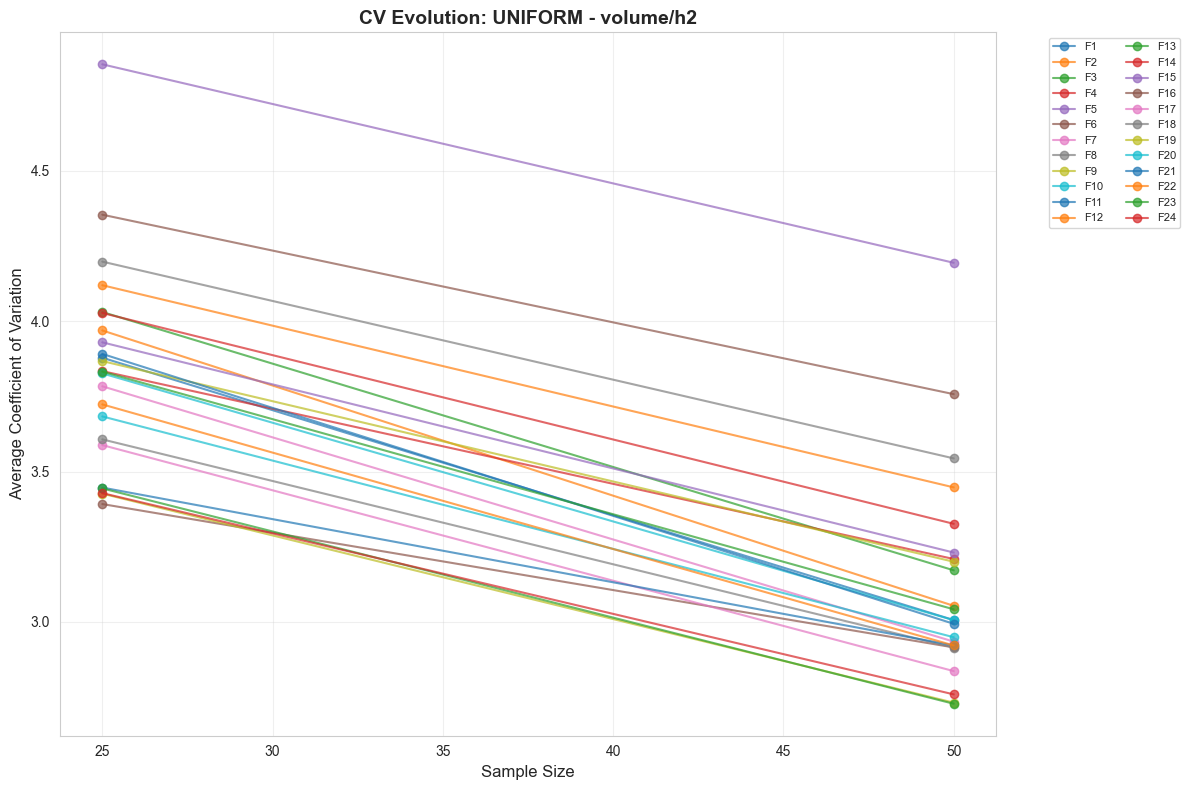

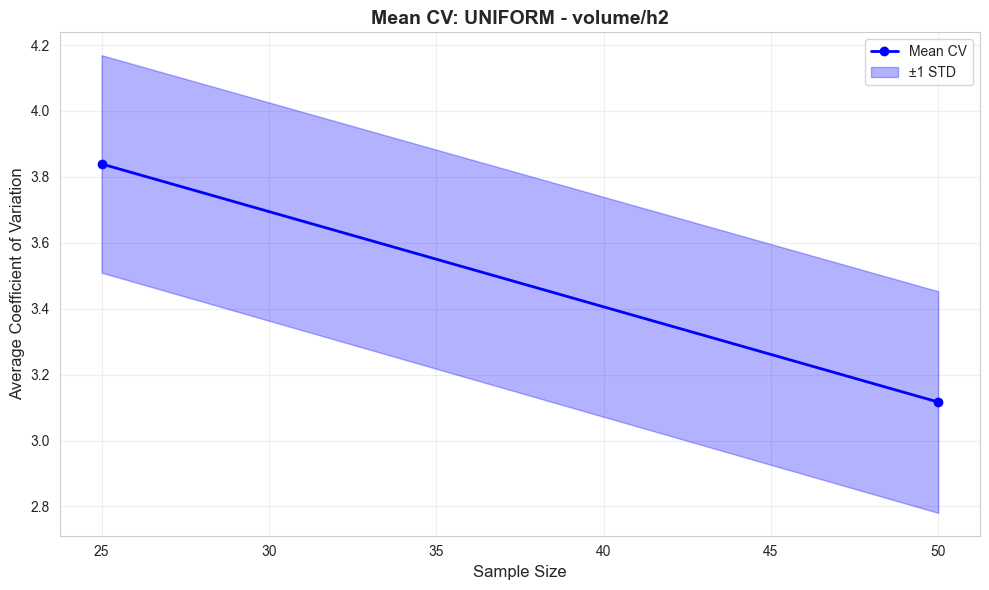


Processing axis/h0...
  Creating plot for: cma - axis/h0


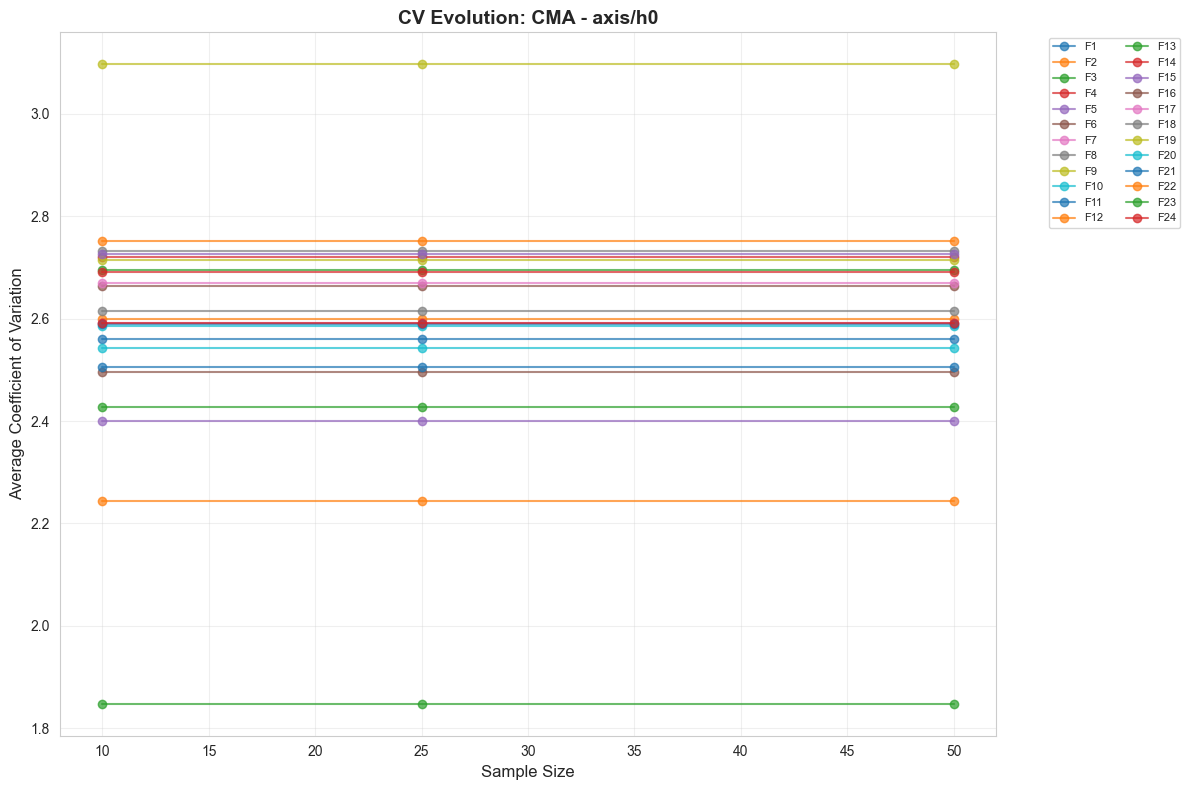

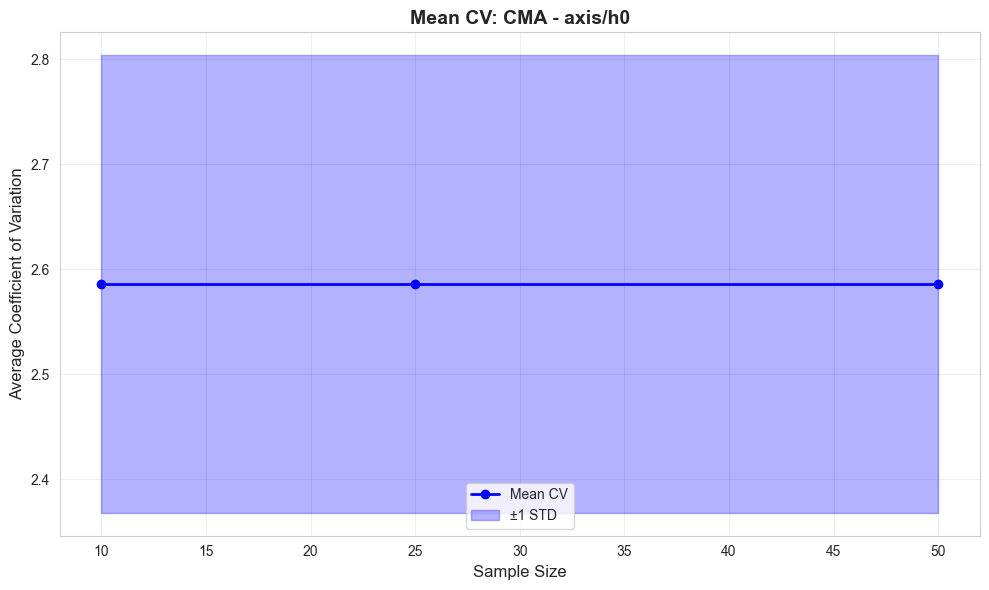

  Creating plot for: ilhs - axis/h0


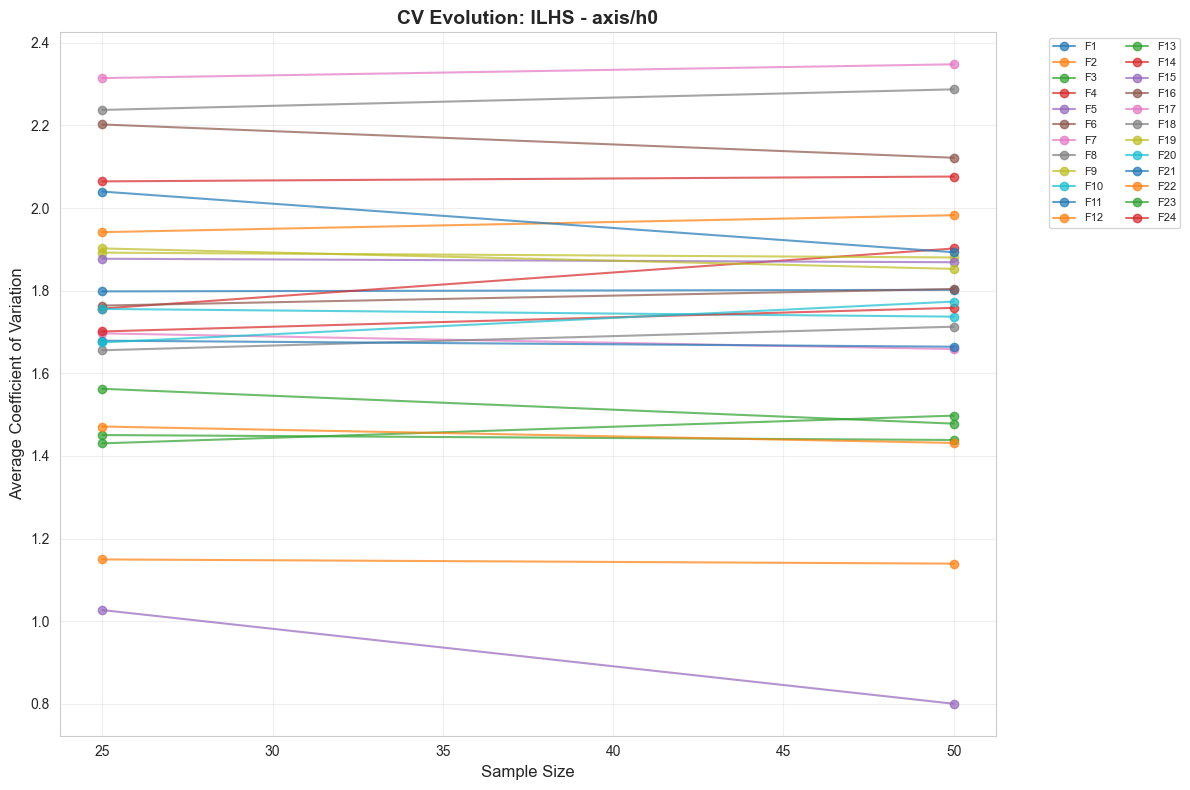

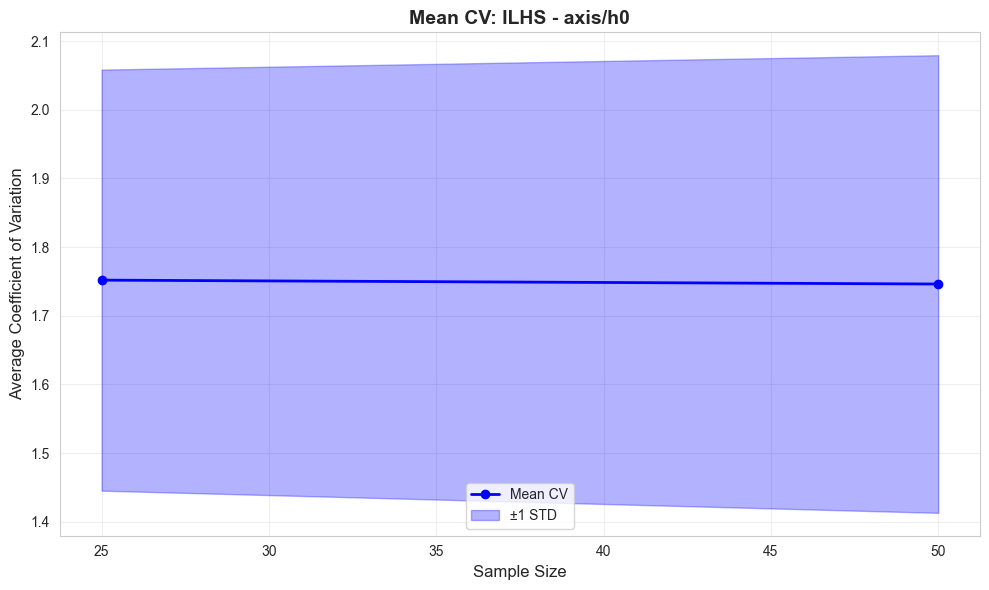

  Creating plot for: lhs - axis/h0


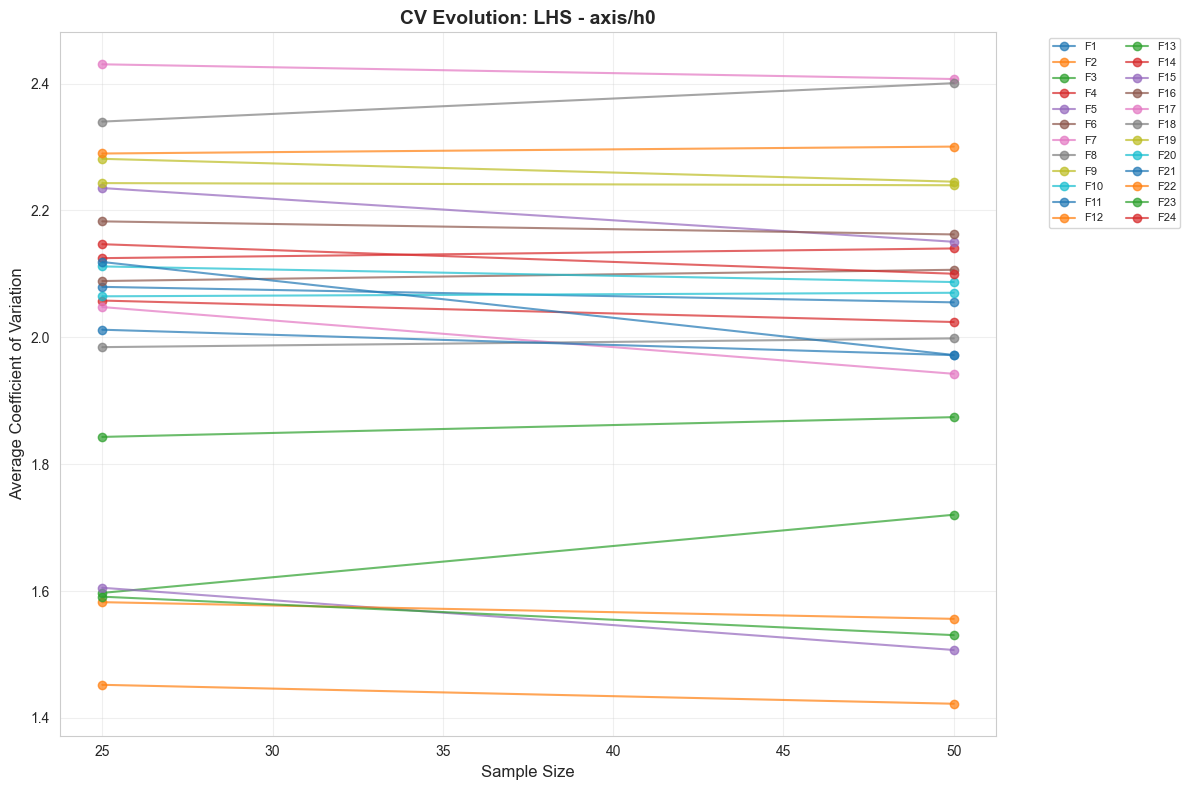

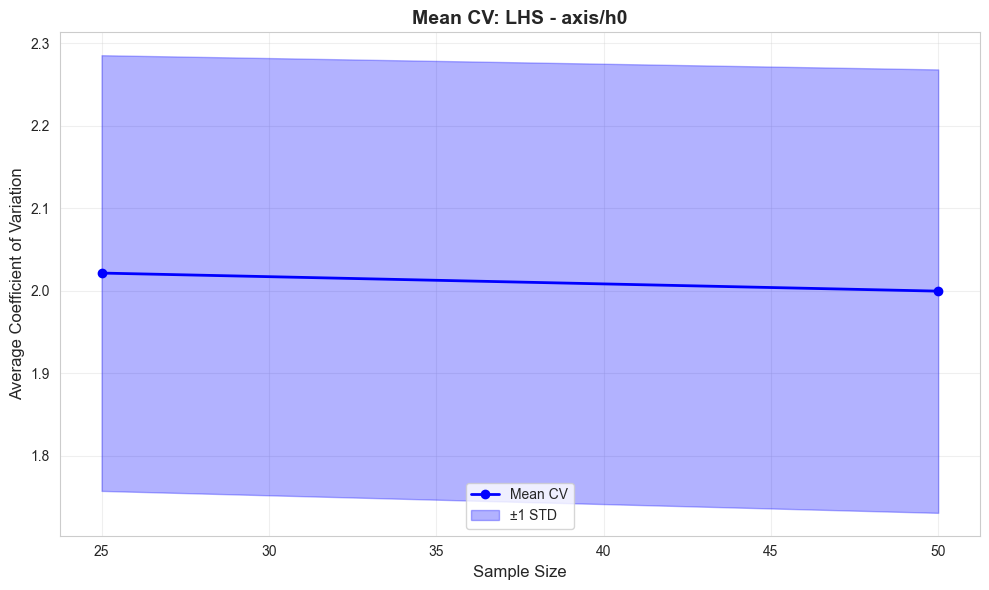

  Creating plot for: sobol - axis/h0


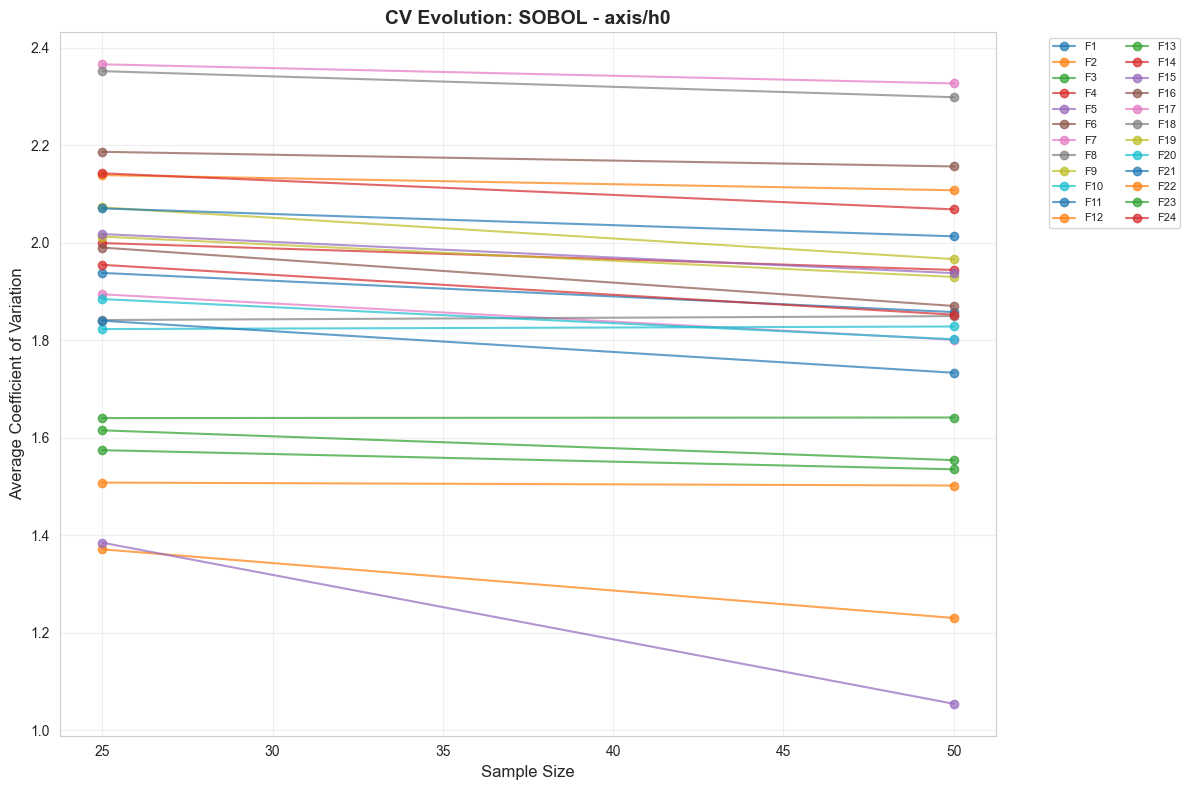

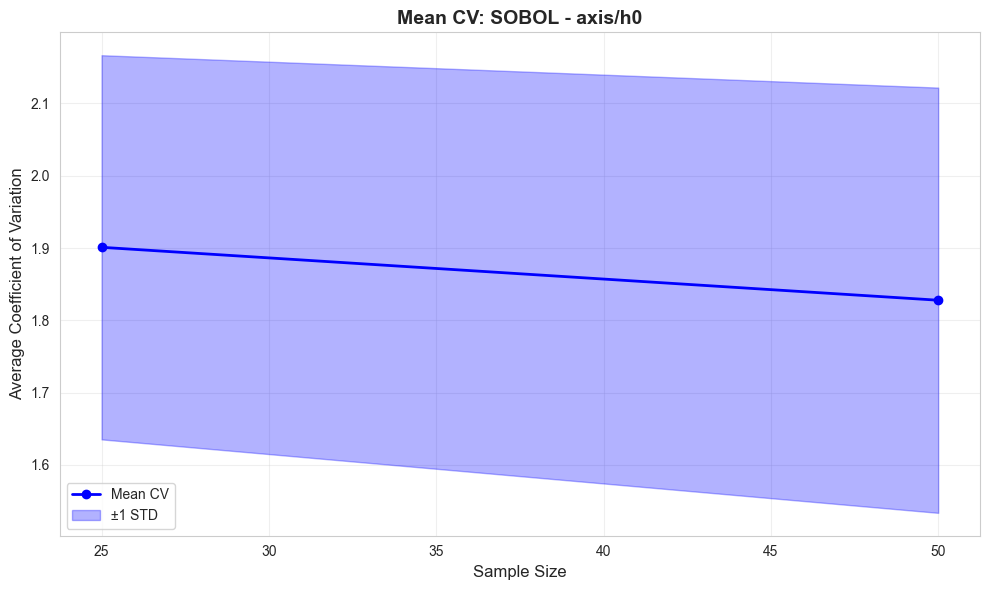

  Creating plot for: uniform - axis/h0


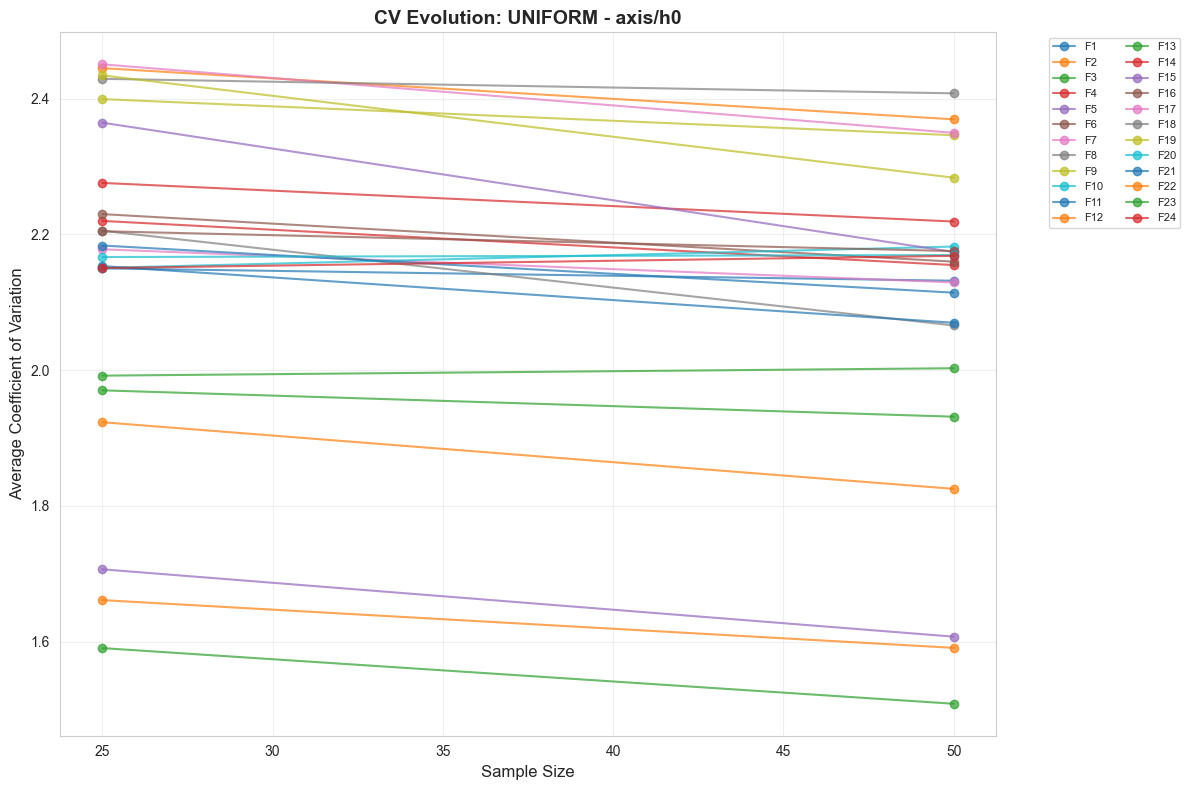

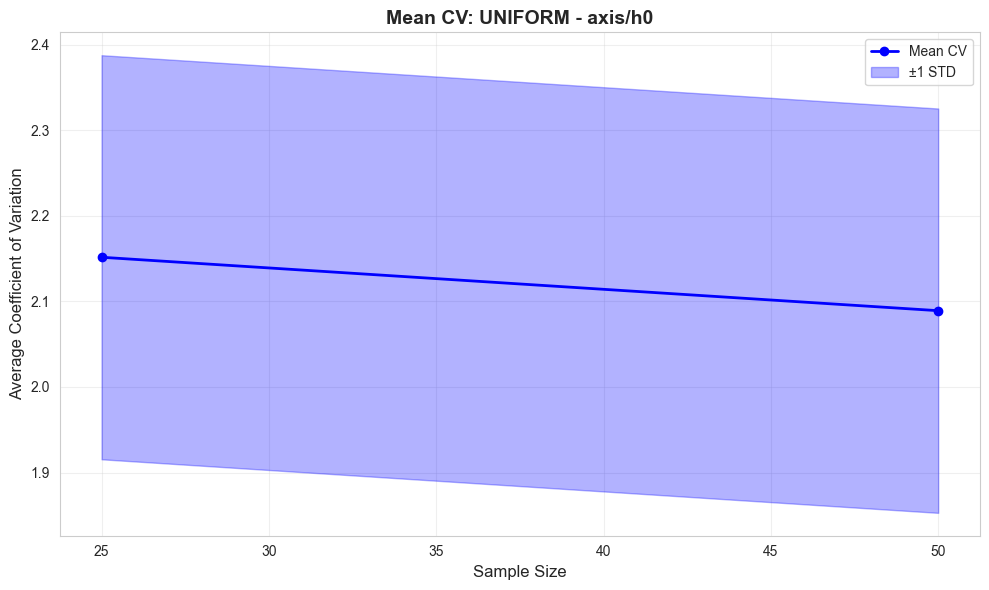


Processing axis/h1...
  Creating plot for: cma - axis/h1


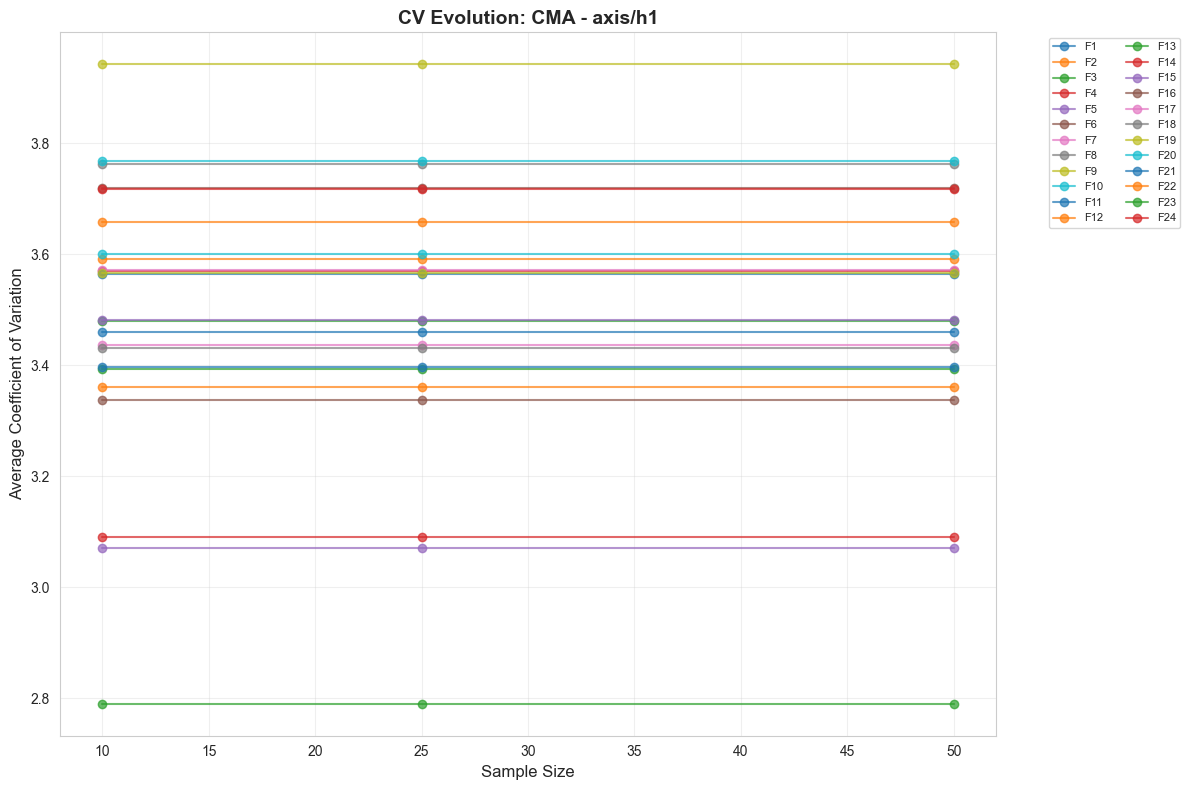

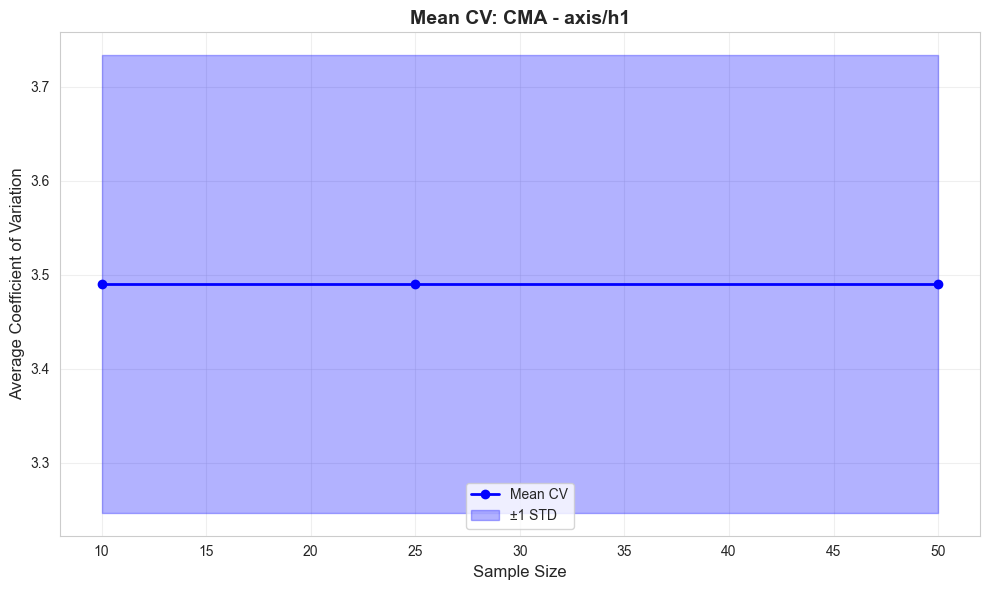

  Creating plot for: ilhs - axis/h1


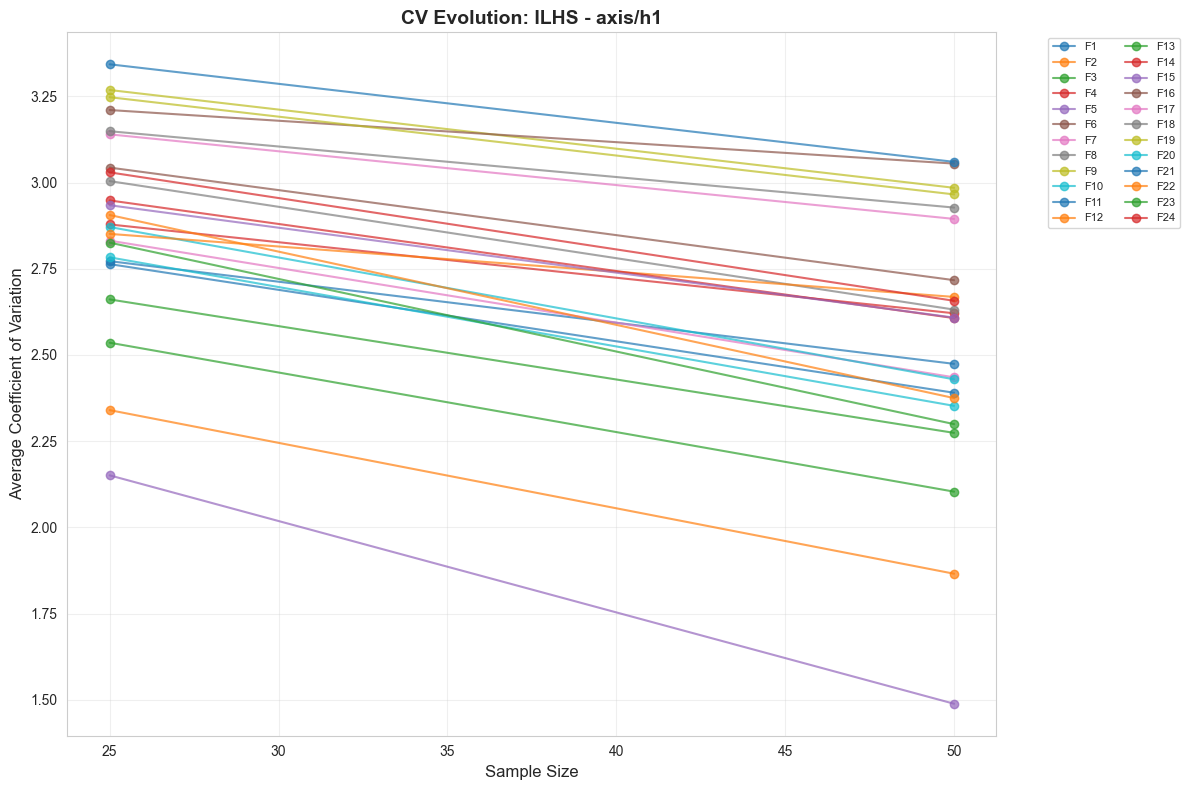

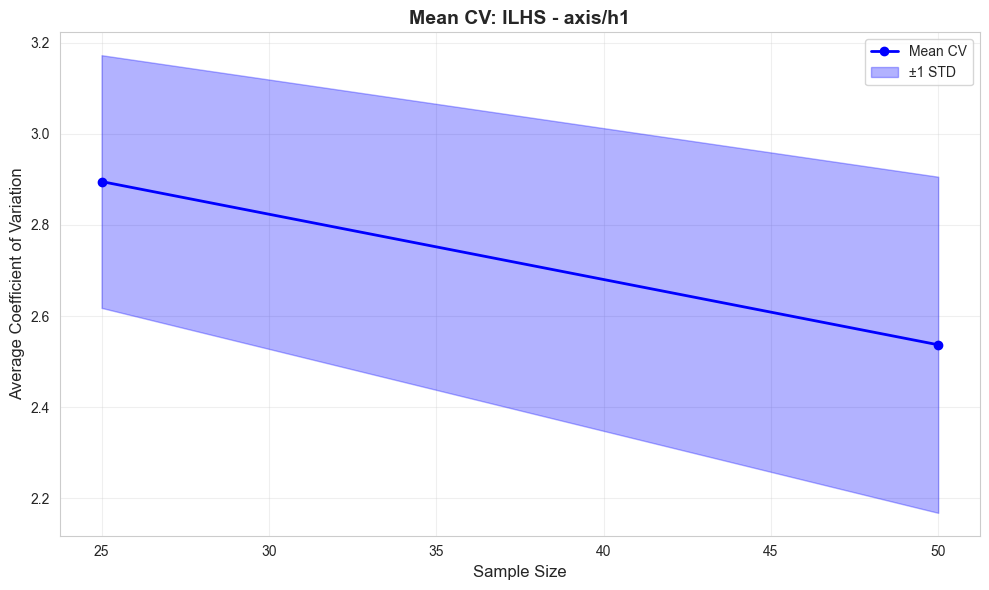

  Creating plot for: lhs - axis/h1


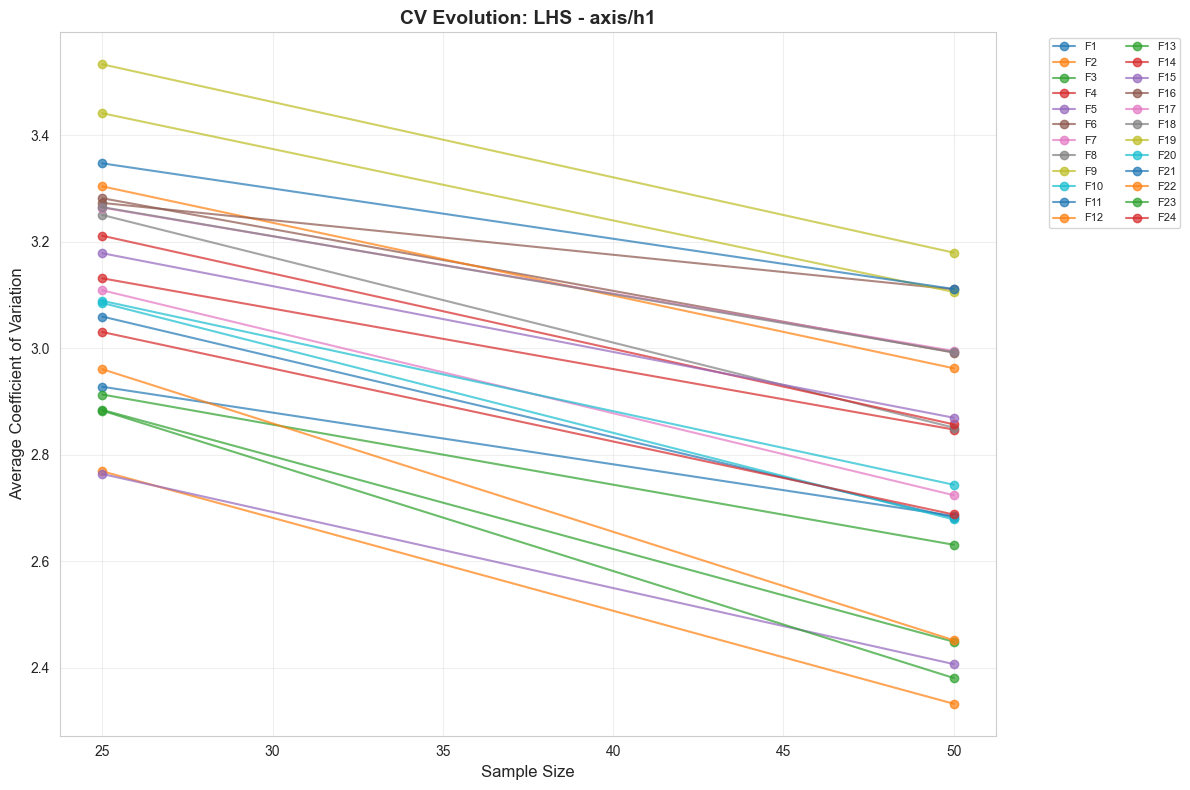

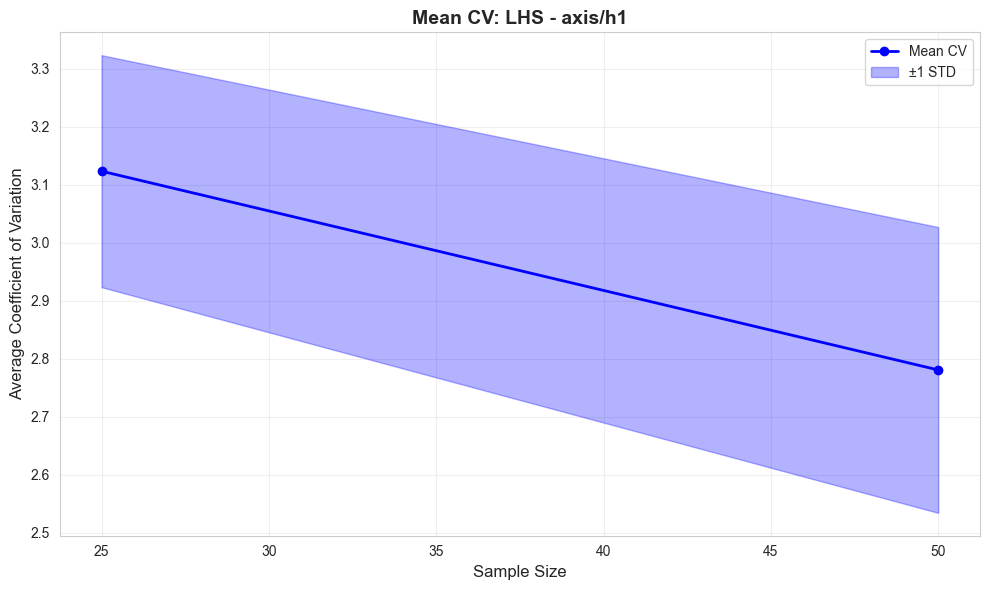

  Creating plot for: sobol - axis/h1


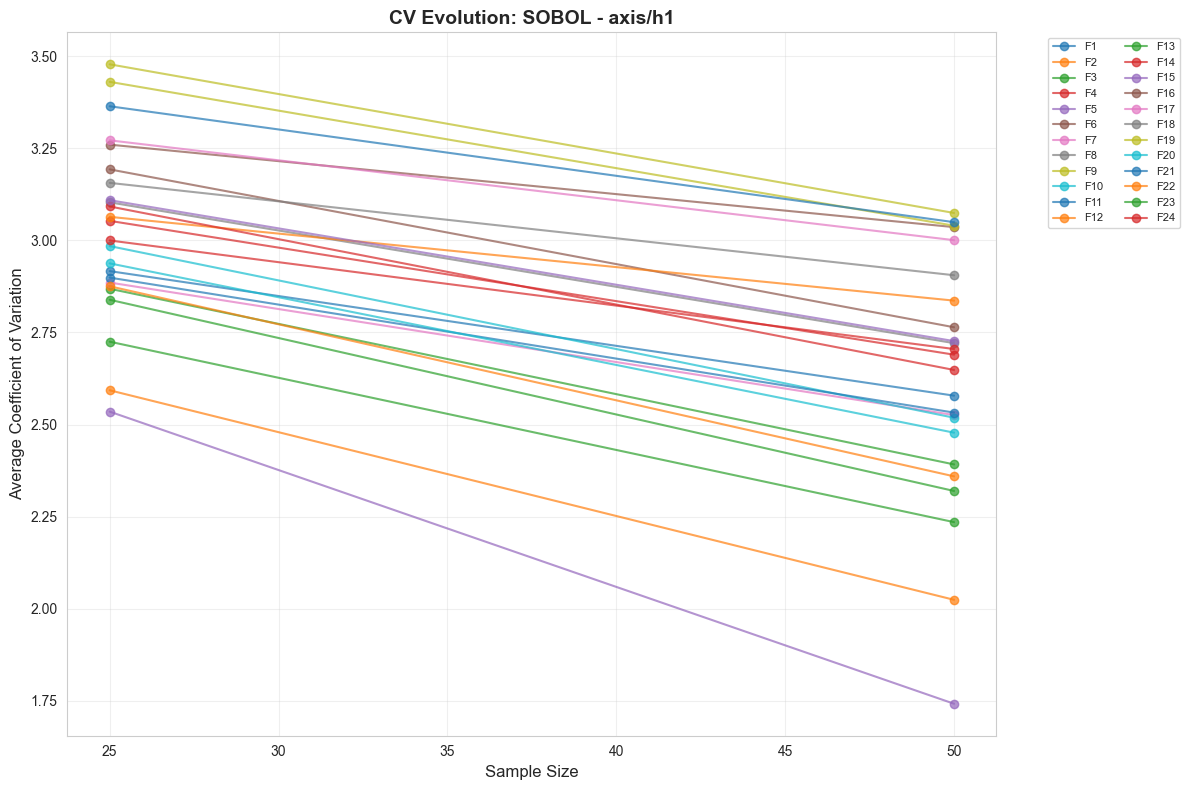

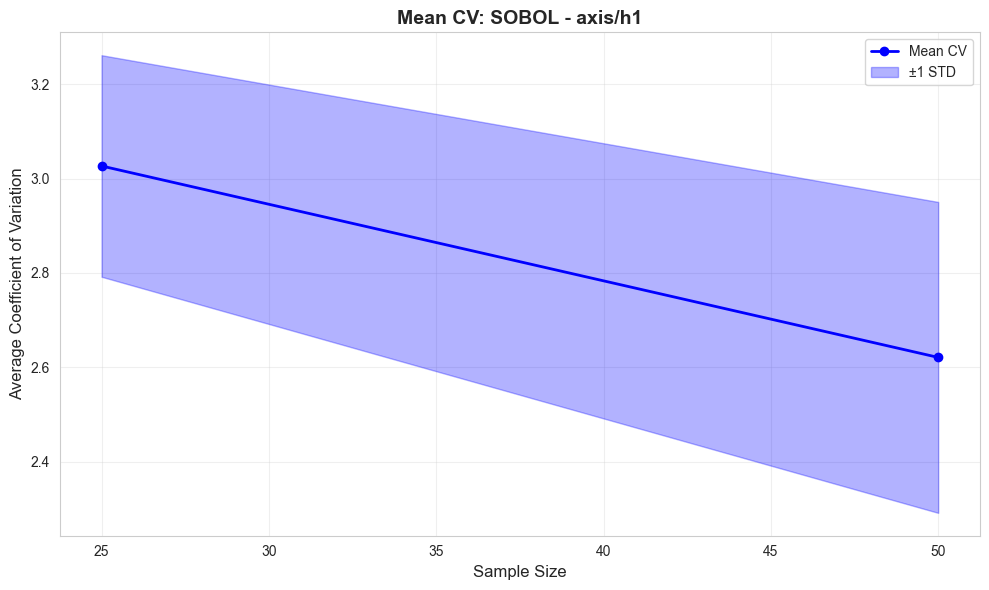

  Creating plot for: uniform - axis/h1


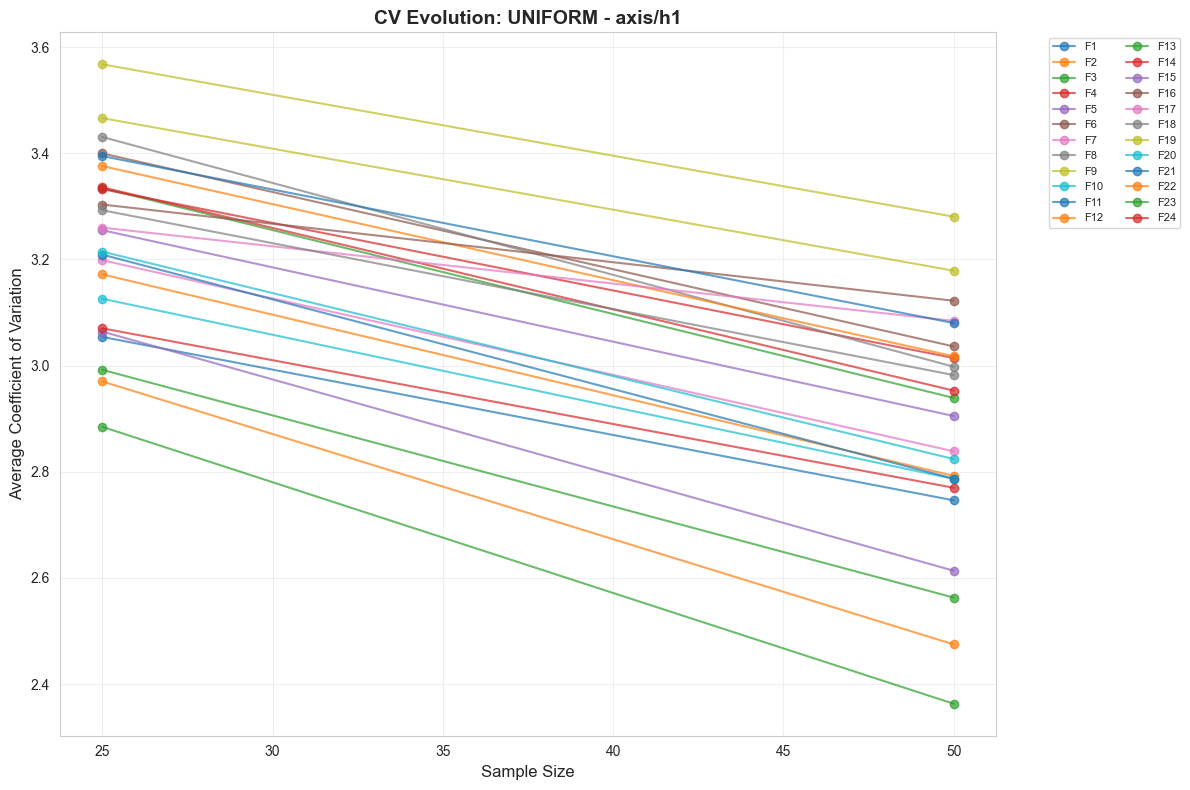

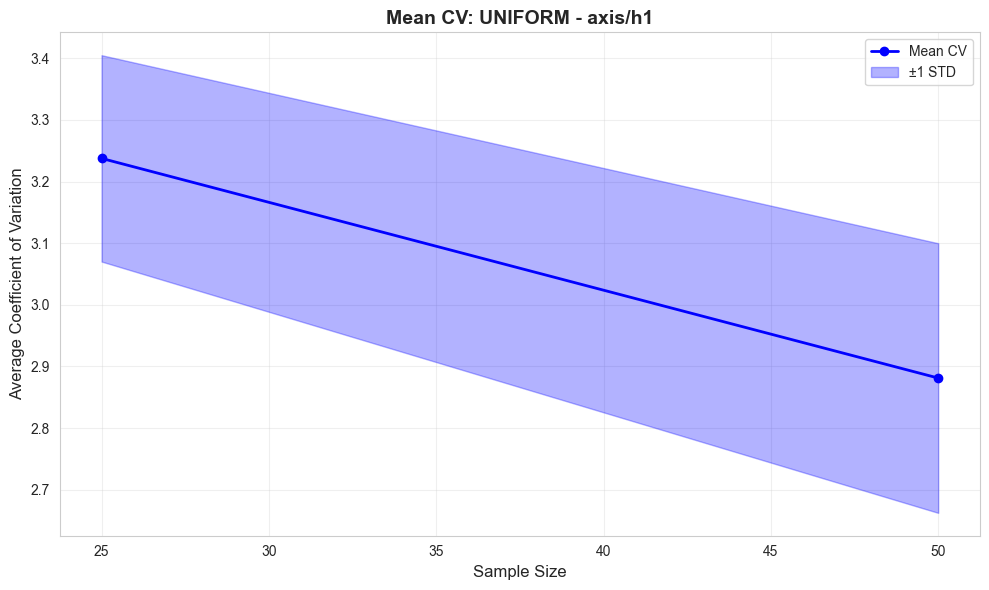


Processing axis/h2...
  Creating plot for: cma - axis/h2


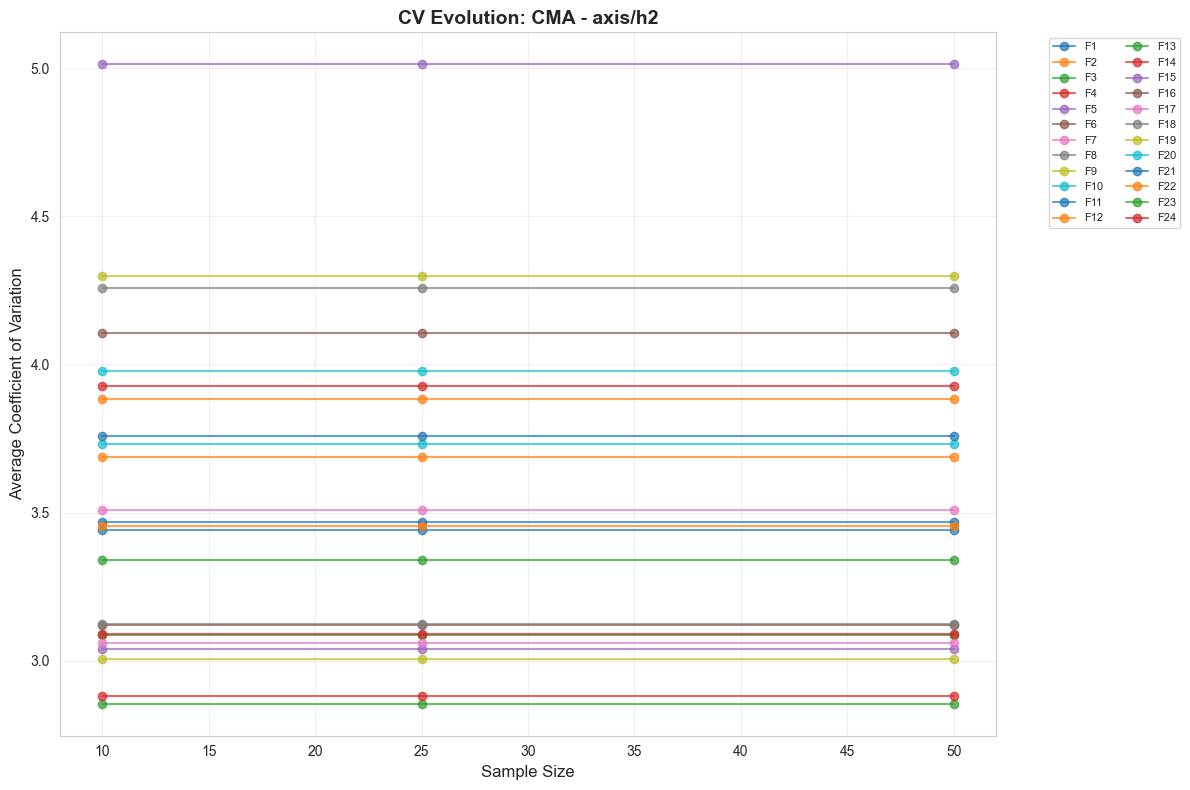

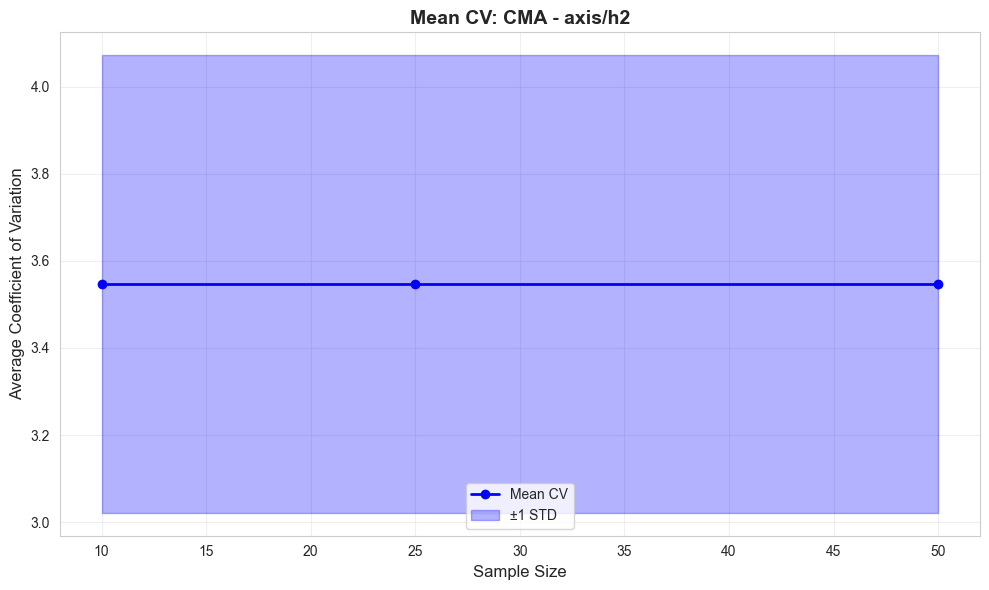

  Creating plot for: ilhs - axis/h2


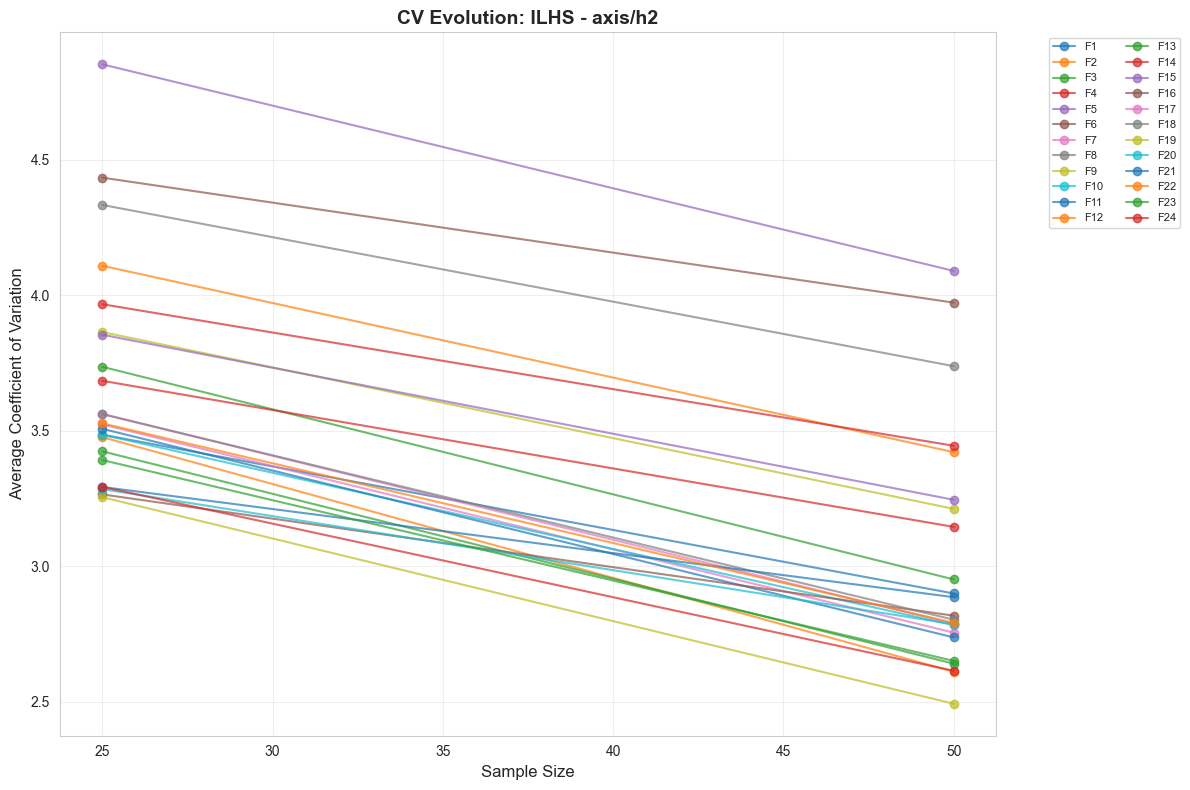

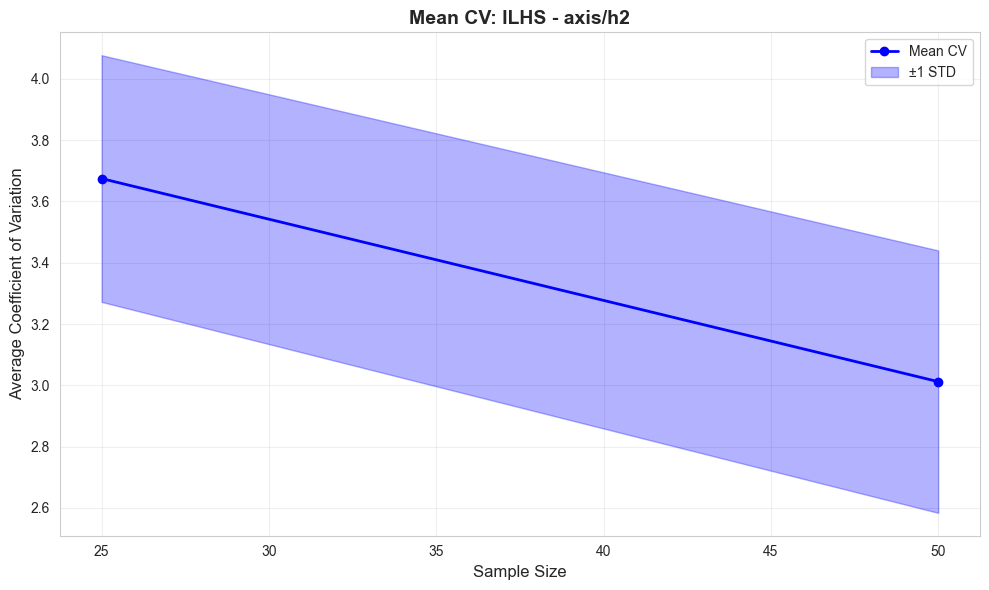

  Creating plot for: lhs - axis/h2


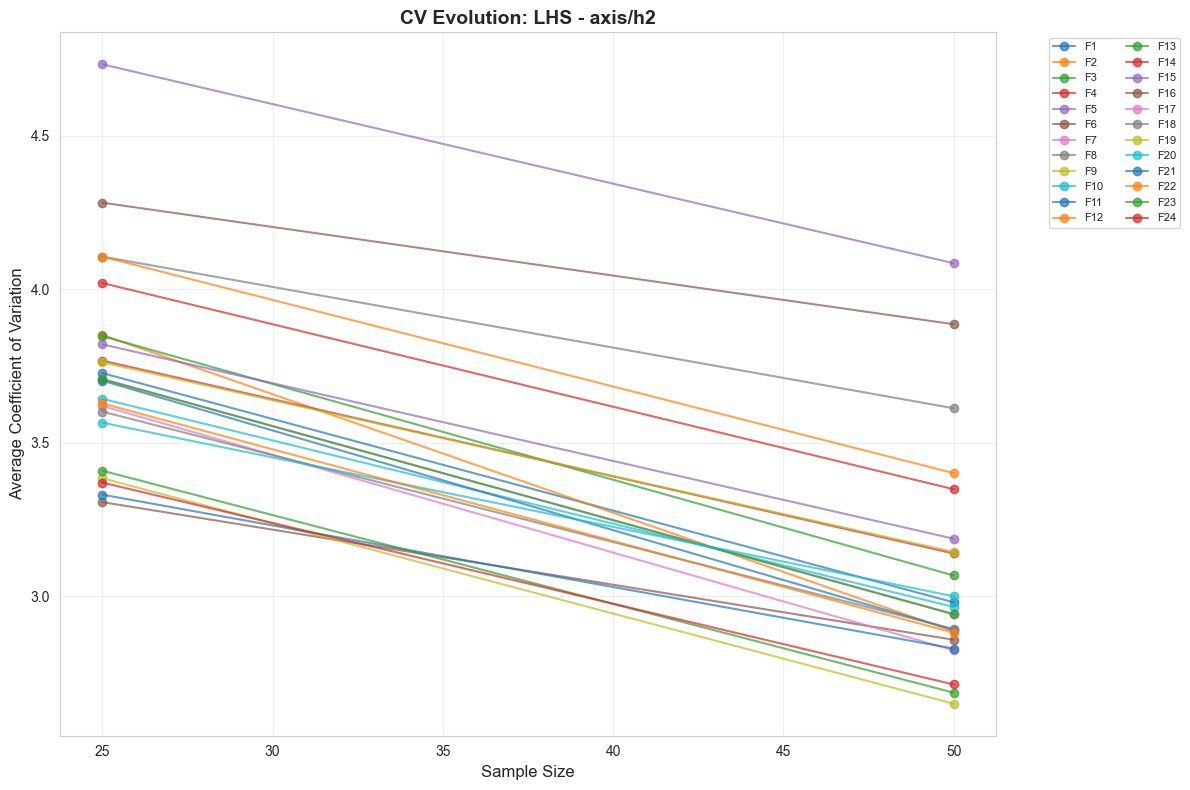

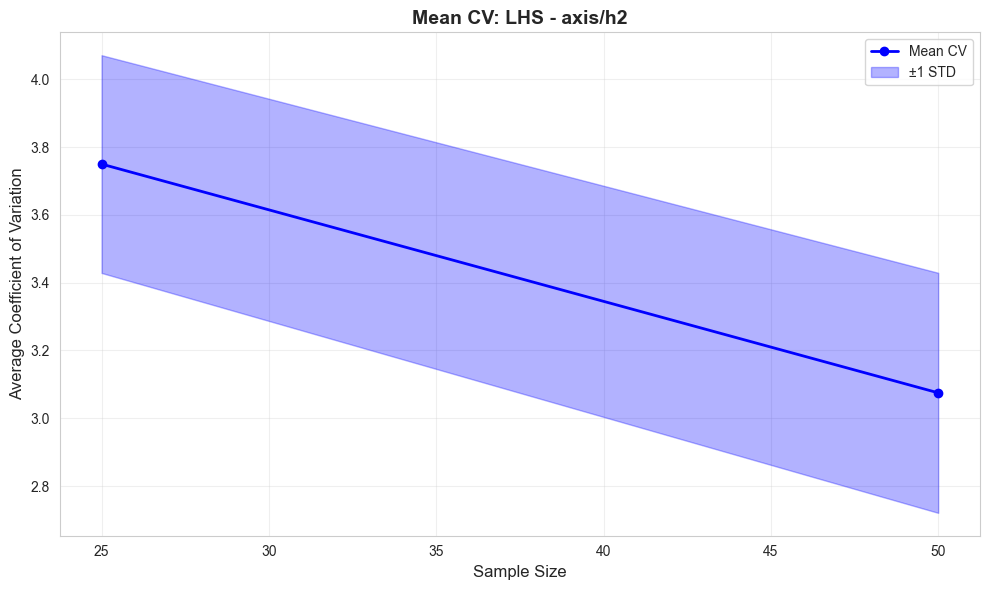

  Creating plot for: sobol - axis/h2


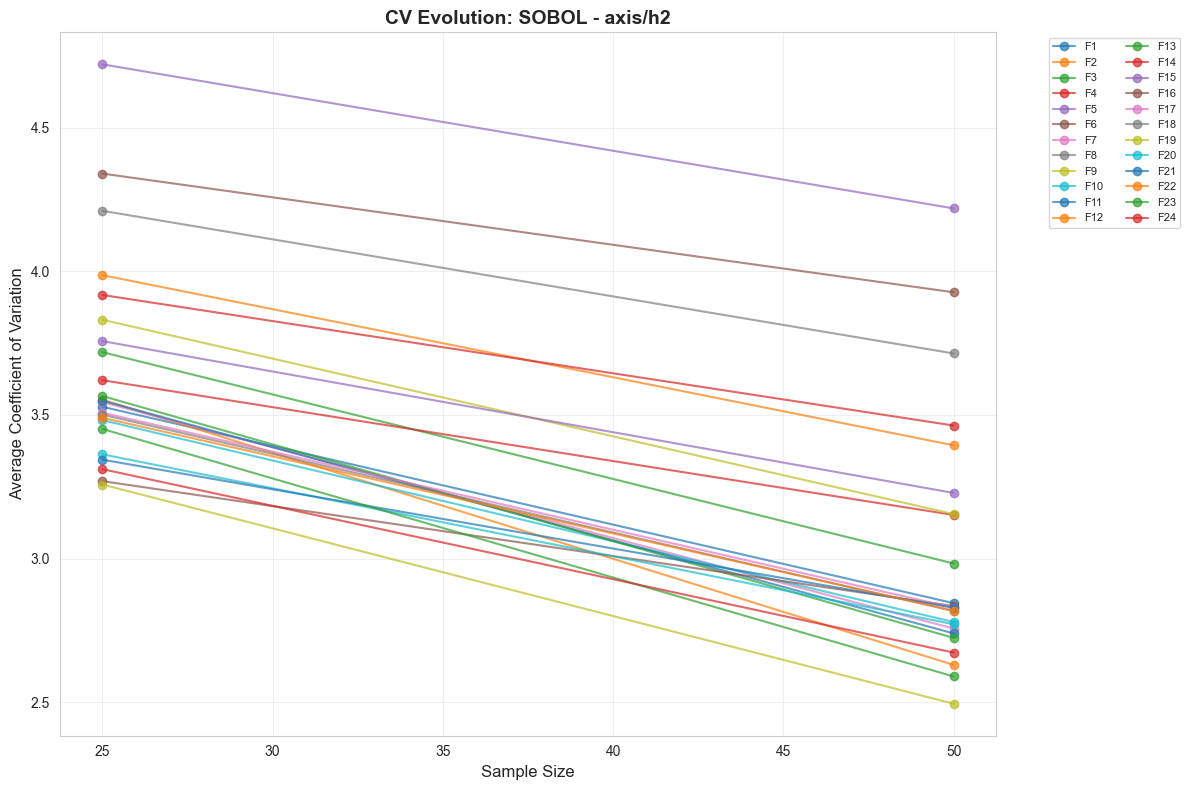

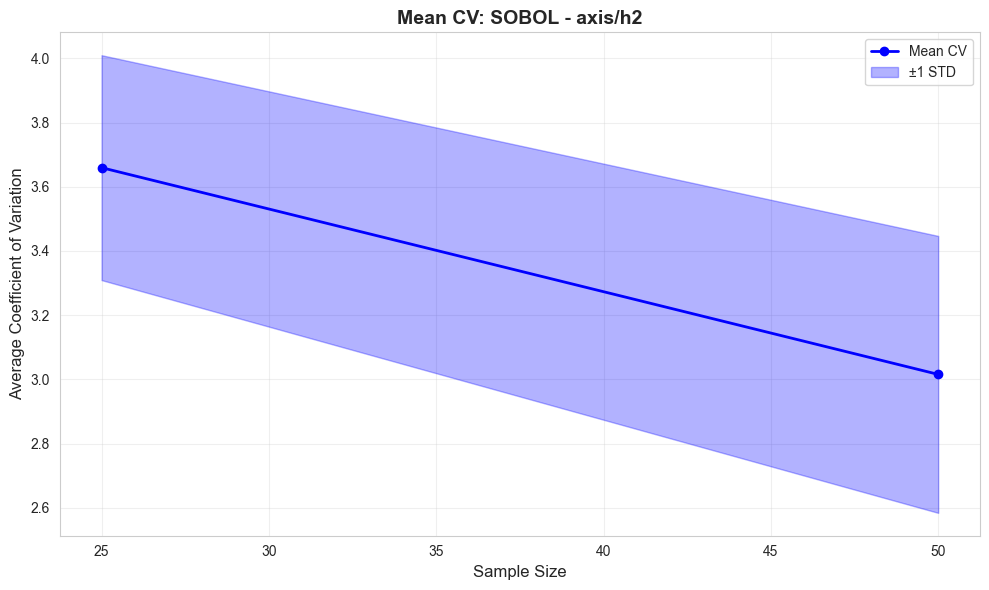

  Creating plot for: uniform - axis/h2


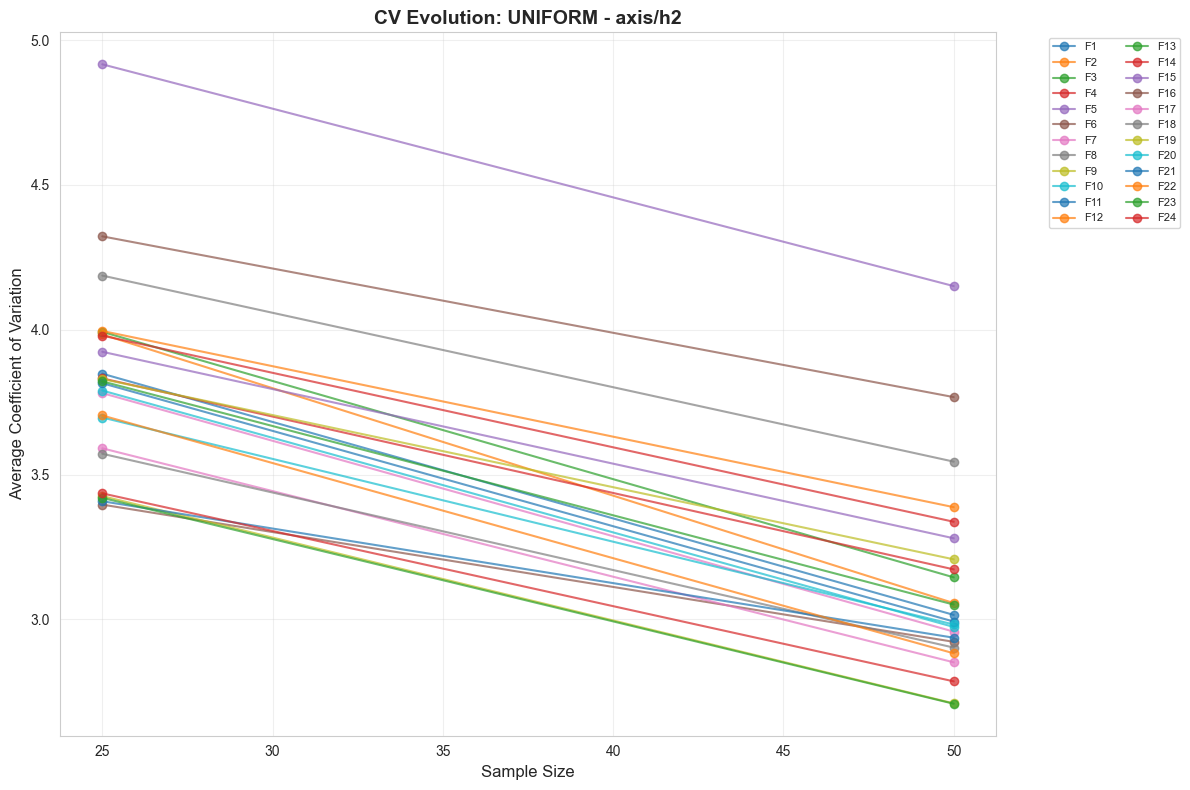

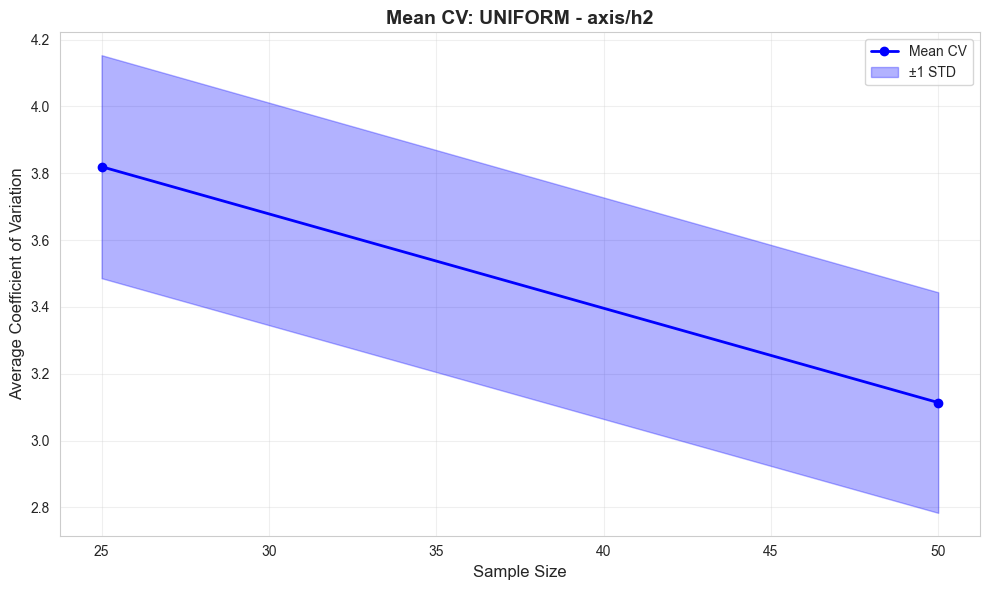

In [55]:
    plot_cv_evolution_by_feature(cv_data)



Creating overall comparison plots...


/var/folders/2x/yr46rn912_91htch_br0s2x80000gn/T/ipykernel_24186/1116243346.py:27: RuntimeWarning: Mean of empty slice
  mean_cv = np.nanmean(cv_array)


  Creating comparison plot for: cma


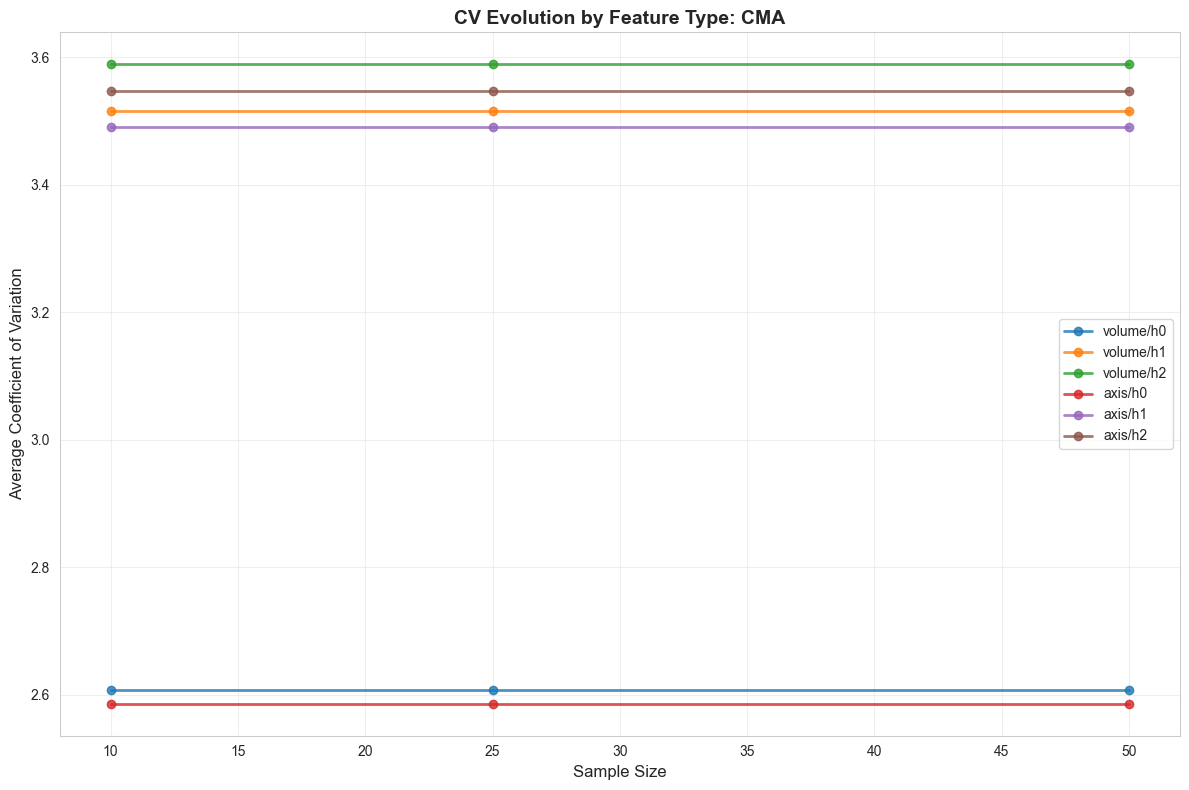

  Creating comparison plot for: ilhs


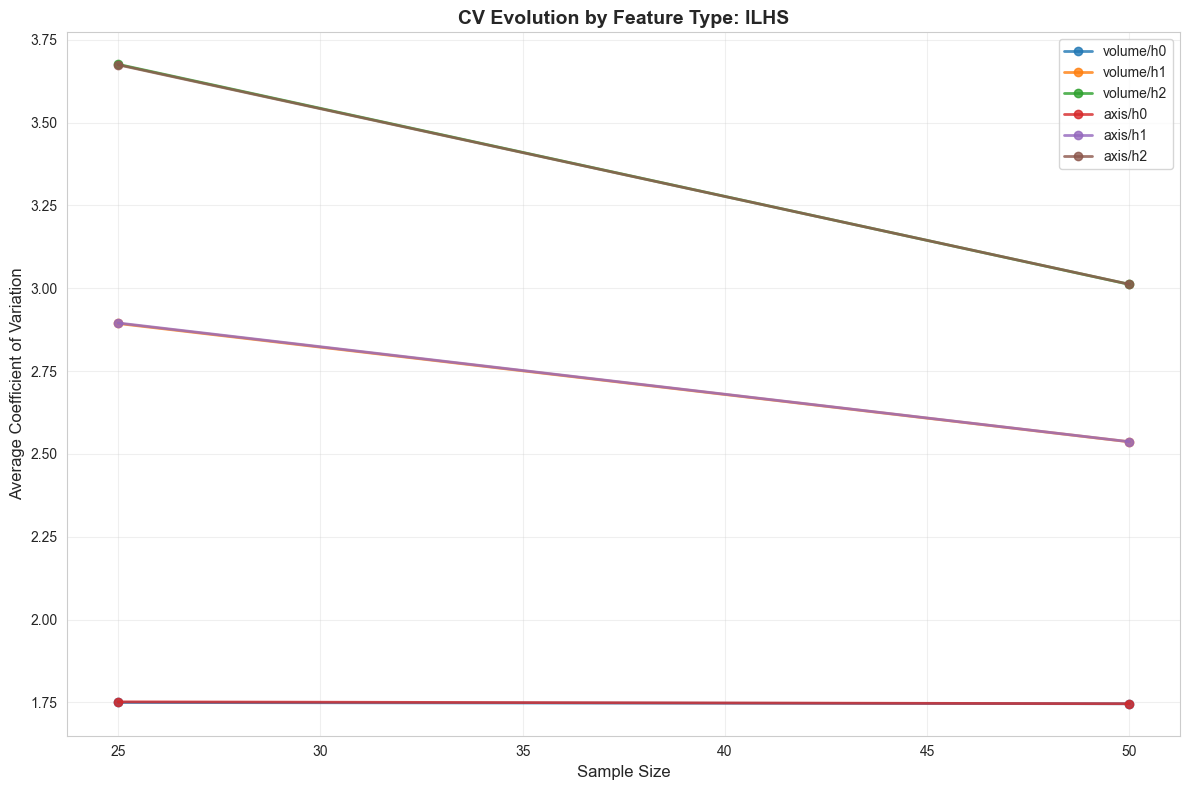

  Creating comparison plot for: lhs


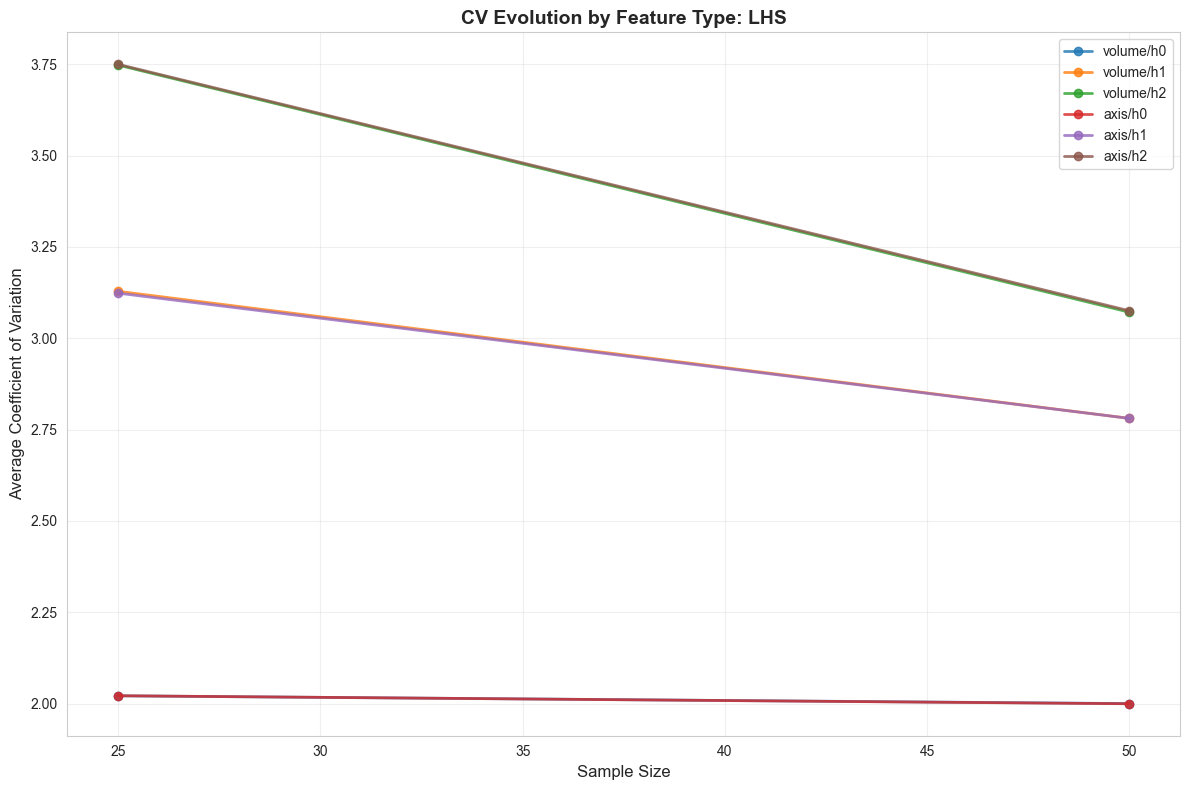

  Creating comparison plot for: sobol


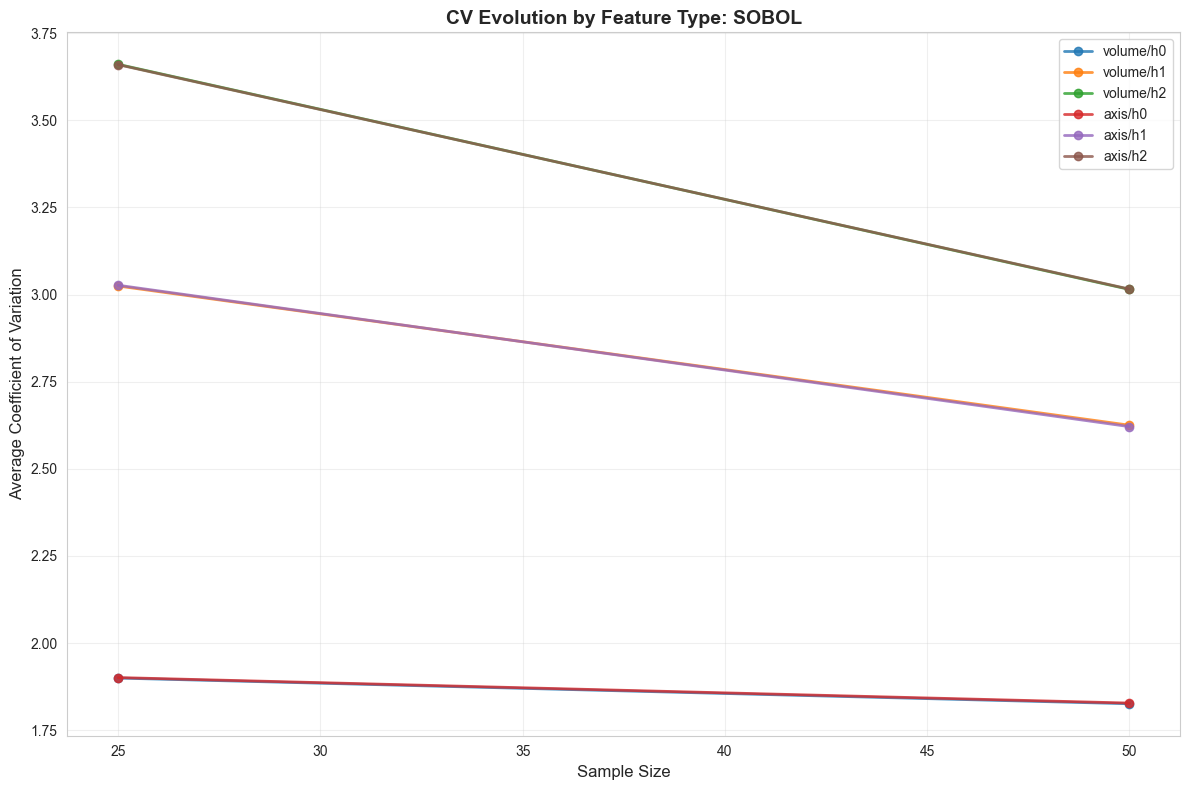

  Creating comparison plot for: uniform


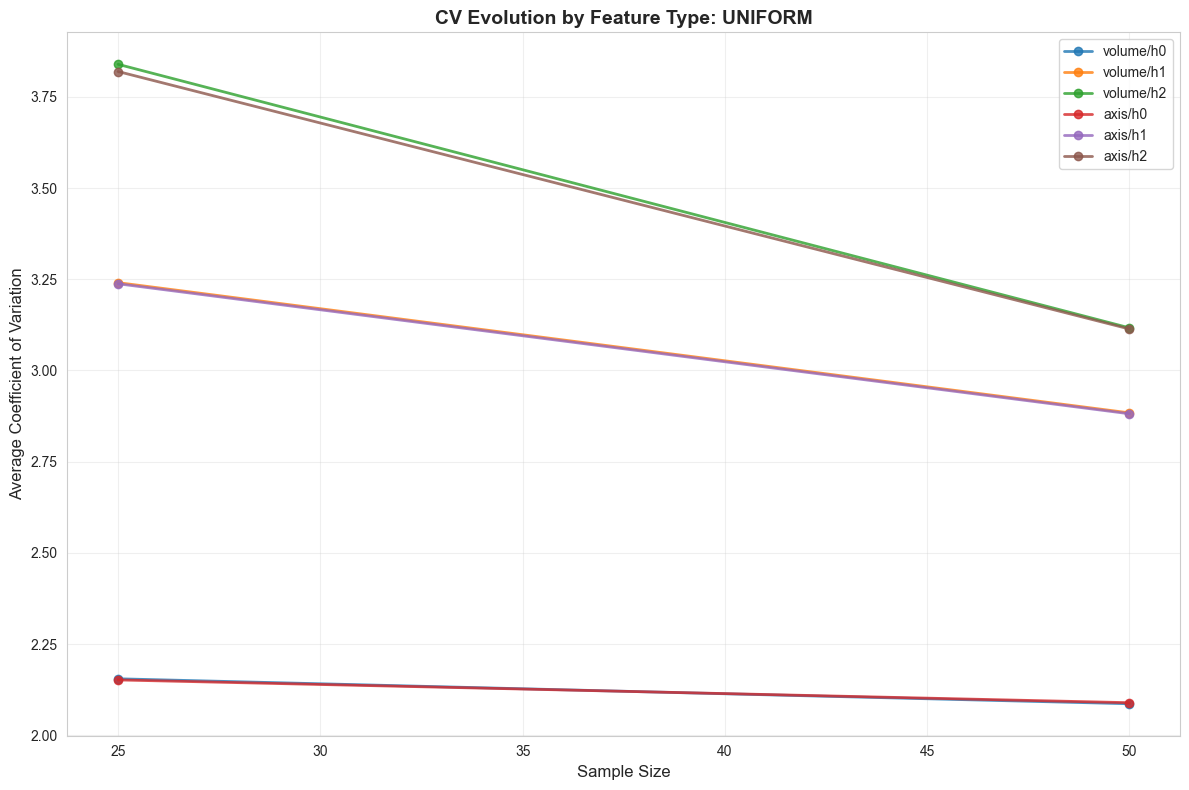

In [56]:
plot_overall_comparison(cv_data)


In [59]:
def compute_overall_cv(cv_dict):
    """
    Compute overall average CV across all functions, instances, transforms, and homologies.

    Args:
        cv_dict: Dictionary with keys (function, instance, dim)

    Returns:
        float: Overall mean CV
    """
    all_cvs = []

    for key, transforms in cv_dict.items():
        function, instance, dim = key

        # Collect CV from all features
        for transform in ['volume', 'axis']:
            if transform not in transforms:
                continue

            for homology in ['h0', 'h1', 'h2']:
                if transforms[transform][homology] is None:
                    continue

                cv_array = transforms[transform][homology]

                # Compute mean CV for this specific configuration
                mean_cv = np.nanmean(cv_array)

                if not np.isnan(mean_cv):
                    all_cvs.append(mean_cv)

    # Return overall mean
    return np.mean(all_cvs) if all_cvs else np.nan


def plot_sampling_methods_comparison(cv_data):
    """
    Create a plot comparing all sampling methods across sample sizes.

    Args:
        cv_data: Loaded CV dictionary
    """

    print("Organizing data by sampling technique...")

    # Organize data: technique -> sample_size -> overall_cv
    technique_data = defaultdict(dict)

    for key_name, cv_dict in cv_data.items():
        technique, sample_size = parse_key(key_name)

        # Compute overall CV for this configuration
        overall_cv = compute_overall_cv(cv_dict)

        technique_data[technique][sample_size] = overall_cv
        print(f"  {technique} @ {sample_size}: CV = {overall_cv:.4f}")

    # Create the comparison plot
    print("\nCreating comparison plot...")

    fig, ax = plt.subplots(figsize=(12, 8))

    # Define colors for each technique (optional, for better distinction)
    colors = plt.cm.tab10(np.linspace(0, 1, len(technique_data)))

    for idx, (technique, sample_size_data) in enumerate(sorted(technique_data.items())):
        # Sort by sample size
        sample_sizes = sorted(sample_size_data.keys())
        cvs = [sample_size_data[size] for size in sample_sizes]

        # Plot line for this technique
        ax.plot(sample_sizes, cvs,
                marker='o',
                linewidth=2.5,
                markersize=8,
                label=technique.upper(),
                color=colors[idx],
                alpha=0.8)

    ax.set_xlabel('Sample Size', fontsize=14, fontweight='bold')
    ax.set_ylabel('Overall Coefficient of Variation', fontsize=14, fontweight='bold')
    ax.set_title('CV Evolution Across Sample Sizes: All Sampling Methods',
                 fontsize=16, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=12, loc='best')

    # Optional: set x-axis to show only actual sample sizes
    ax.set_xticks(sorted(set([size for data in technique_data.values() for size in data.keys()])))

    plt.tight_layout()

    plt.show()
    plt.close()

    # Also create a table summary
    print("\n" + "="*60)
    print("Summary Table:")
    print("="*60)

    # Get all sample sizes
    all_sample_sizes = sorted(set([size for data in technique_data.values() for size in data.keys()]))

    # Print header
    header = "Technique".ljust(15) + "".join([f"{size}".rjust(12) for size in all_sample_sizes])
    print(header)
    print("-"*60)

    # Print each technique
    for technique in sorted(technique_data.keys()):
        row = technique.ljust(15)
        for size in all_sample_sizes:
            if size in technique_data[technique]:
                cv = technique_data[technique][size]
                row += f"{cv:.4f}".rjust(12)
            else:
                row += "N/A".rjust(12)
        print(row)

    print("="*60)


Organizing data by sampling technique...


/var/folders/2x/yr46rn912_91htch_br0s2x80000gn/T/ipykernel_24186/4149334125.py:28: RuntimeWarning: Mean of empty slice
  mean_cv = np.nanmean(cv_array)


  cma @ 10: CV = 3.2212
  cma @ 25: CV = 3.2212
  cma @ 50: CV = 3.2212
  ilhs @ 25: CV = 2.7690
  ilhs @ 50: CV = 2.4316
  lhs @ 25: CV = 2.9629
  lhs @ 50: CV = 2.6177
  sobol @ 25: CV = 2.8586
  sobol @ 50: CV = 2.4882
  uniform @ 25: CV = 3.0721
  uniform @ 50: CV = 2.6951

Creating comparison plot...


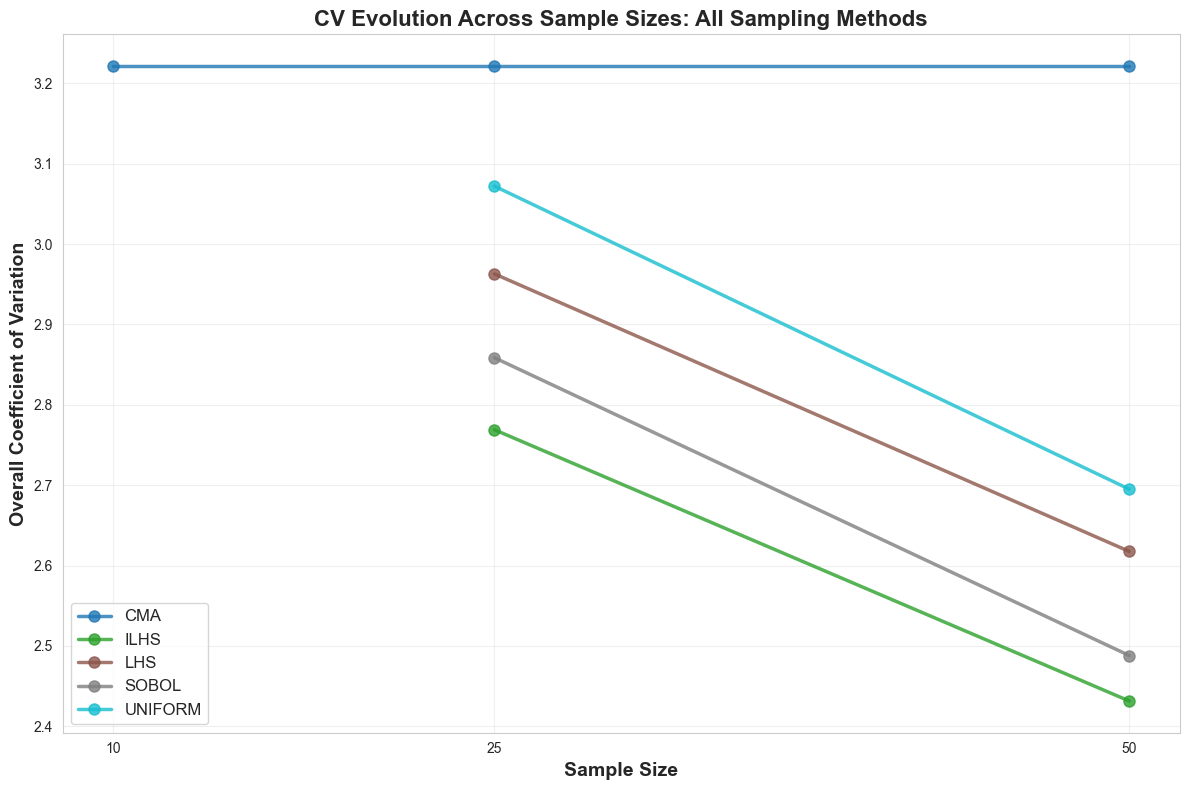


Summary Table:
Technique                10          25          50
------------------------------------------------------------
cma                  3.2212      3.2212      3.2212
ilhs                    N/A      2.7690      2.4316
lhs                     N/A      2.9629      2.6177
sobol                   N/A      2.8586      2.4882
uniform                 N/A      3.0721      2.6951


In [60]:
    plot_sampling_methods_comparison(cv_data)
